# Hier-COS Output Analysis

This notebook analyzes seeded training/test artifacts in `/scratch/g.saggini1/outputs/` and compares Hier-COS variants across datasets. Each experiment is a parent directory containing `seed_<seed>` runs; curves and final metrics report the mean and sample standard deviation across those seeds.

Default setup:
- baselines: `hiercos_<dataset>_global_softmax_ce_reg_baseline_<weight>` with `equal` and `kl_leaf`
- lexicographic runs: `hiercos_<dataset>_global_softmax_ce_reg_lex_<mode>`
- coarse-first transform ablations: `hiercos_<dataset>_global_softmax_ce_reg_lex_coarse_first_<transform>`
- targeted normalization ablation: run with `model.loss=level_softmax_ce_reg` using explicit output directories

It includes:
- validation curves for `FPA`, `weighted AP`, `TICE`, and `AHD`,
- per-level validation top-down/independent accuracy curves,
- training loss comparisons (`total`, `ce`, `reg`, `kl`, and exact weighted `loss_level_*` when available),
- optional projection/gradient diagnostics when those metrics are present in logs,
- final test comparison tables with deltas versus dataset baseline.


In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = next((p for p in [cwd, *cwd.parents] if (p / 'configs').is_dir()), cwd)
notebook_utils_dir = repo_root / 'notebooks' / 'utils'
if str(notebook_utils_dir) not in sys.path:
    sys.path.insert(0, str(notebook_utils_dir))

from hcast_analysis_utils import (
    HCastAnalysis as HierCosAnalysis,
    HCastAnalysisConfig as HierCosAnalysisConfig,
    resolve_project_root,
)

PROJECT_ROOT = resolve_project_root()
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
print(f'Using project root: {PROJECT_ROOT}')


Using project root: /home/g.saggini1/lexicographic_deep_learning_detailed_study


In [2]:
INCLUDE_BASELINES = True
INCLUDE_TOPDOWN_METRICS = False
BASELINE_COLOR = "#243ab4"

BASELINE_BY_DATASET = {
    'cifar-100': {'run_dir': 'hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS global softmax kl_leaf baseline'},
    'cub-200-2011': {'run_dir': 'hiercos_cub200_global_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS global softmax kl_leaf baseline'},
    'fgvc-aircraft': {'run_dir': 'hiercos_aircraft_global_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS global softmax kl_leaf baseline'},
}

MANUAL_RUNS = [
    # Equal-weight non-lex baselines
    # {'run_dir': 'hiercos_cifar100_global_softmax_ce_reg_baseline_equal', 'label': 'Hier-COS global softmax equal baseline'},
    # {'run_dir': 'hiercos_cub200_global_softmax_ce_reg_baseline_equal', 'label': 'Hier-COS global softmax equal baseline'},
    # {'run_dir': 'hiercos_aircraft_global_softmax_ce_reg_baseline_equal', 'label': 'Hier-COS global softmax equal baseline'},

    
    # level-softmax-ce-reg
    # {'run_dir': 'hiercos_cifar100_level_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS level softmax kl_leaf baseline'},
    # {'run_dir': 'hiercos_cub200_level_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS level softmax kl_leaf baseline'},
    # {'run_dir': 'hiercos_aircraft_level_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS level softmax kl_leaf baseline'},
    
    #{'run_dir': 'hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf_identity', 'label': 'Hier-COS global softmax kl_leaf_identity baseline'},
    # {'run_dir': 'hiercos_cub200_global_softmax_ce_reg_baseline_kl_leaf_identity', 'label': 'Hier-COS global softmax kl_leaf_identity baseline'},
    # {'run_dir': 'hiercos_aircraft_global_softmax_ce_reg_baseline_kl_leaf_identity', 'label': 'Hier-COS global softmax kl_leaf_identity baseline'},
    #{'run_dir': 'hiercos_aircraft_global_softmax_ce_reg_fromscratch_kl_leaf_identity', 'label': 'Hier-COS global softmax identity kl_leaf from scratch'},     
       
    # level-softmax-ce-reg identity
    # {'run_dir': 'hiercos_cifar100_level_softmax_ce_reg_baseline_kl_leaf_identity', 'label': 'Hier-COS level softmax kl_leaf_identity baseline'},
    # {'run_dir': 'hiercos_cub200_level_softmax_ce_reg_baseline_kl_leaf_identity', 'label': 'Hier-COS level softmax kl_leaf_identity baseline'},
    # {'run_dir': 'hiercos_aircraft_level_softmax_ce_reg_baseline_kl_leaf_identity', 'label': 'Hier-COS level softmax kl_leaf_identity baseline'},

    # {'run_dir': 'hiercos_cifar100_level_softmax_ce_reg_baseline_kl_leaf_d512_identity', 'label': 'Hier-COS level softmax kl_leaf d512 identity baseline'},
    # {'run_dir': 'hiercos_cub200_level_softmax_ce_reg_baseline_kl_leaf_d512_identity', 'label': 'Hier-COS level softmax kl_leafv d512 identity baseline'},
    # {'run_dir': 'hiercos_aircraft_level_softmax_ce_reg_baseline_kl_leaf_d512_identity', 'label': 'Hier-COS level softmax kl_leaf d512 identity baseline'},
    
    # Global-softmax lex runs
    *[
        {'run_dir': f'hiercos_{dataset}_global_softmax_ce_reg_lex_{mode}',
         'label': f'Hier-COS global softmax {mode}'}
        for dataset in ('cifar100', 'cub200', 'aircraft')
        for mode in ('coarse_first',)
    ],

    #{'run_dir': 'hiercos_cifar100_global_softmax_ce_reg_resnet50pretrained_kl_leaf_identity', 'label': 'Hier-COS global softmax kl_leaf identity resnet50 pretrain'},
    #{'run_dir': 'hiercos_cifar100_global_softmax_ce_reg_resnet50pretrained_kl_leaf', 'label': 'Hier-COS global softmax kl_leaf resnet50 pretrain'},
    #{'run_dir': 'hiercos_cifar100_global_softmax_ce_reg_resnet50scratch_kl_leaf_identity', 'label': 'Hier-COS global softmax kl_leaf identity resnet50 scratch'},
    
    *[
        {'run_dir': f'hiercos_{dataset}_global_softmax_ce_reg_lex_{mode}_identity',
         'label': f'Hier-COS global softmax {mode} identity'}
        for dataset in ('cifar100', 'cub200', 'aircraft')
        for mode in ('coarse_first',)
    ],
    *[
        {'run_dir': f'hiercos_{dataset}_subspace',
         'label': f'Hier-COS gsubspace'}
        for dataset in ('cifar100', 'cub200', 'aircraft')
    ],
    # *[
    #     {'run_dir': f'hiercos_{dataset}_global_softmax_ce_reg_lex_{mode}_kl_leaf',
    #      'label': f'Hier-COS global softmax {mode} kl_leaf'}
    #     for dataset in ('cifar100', 'cub200', 'aircraft')
    #     for mode in ('coarse_first',)
    # ],
    # Level-softmax lexicographic runs
    # *[
    #     {'run_dir': f'hiercos_{dataset}_level_softmax_ce_reg_lex_{mode}',
    #      'label': f'Hier-COS level softmax {mode}'}
    #     for dataset in ('cifar100', 'cub200', 'aircraft')
    #     for mode in ('coarse_first',)
    # ],
        # *[
    # *[
    #     {'run_dir': f'hiercos_{dataset}_level_softmax_ce_reg_lex_{mode}_identity',
    #      'label': f'Hier-COS level softmax {mode} identity'}
    #     for dataset in ('cifar100', 'cub200', 'aircraft')
    #     for mode in ('coarse_first',)
    # ],
    {'run_dir': 'hiercos_cifar100_level_softmax_ce_reg_projection_kl_leaf_identity', 'label': 'Hier-COS level softmax projection identity kl_leaf'}, 
    {'run_dir': 'hiercos_cub200_level_softmax_ce_reg_projection_kl_leaf_identity', 'label': 'Hier-COS level softmax projection identity kl_leaf'}, 
    {'run_dir': 'hiercos_aircraft_level_softmax_ce_reg_projection_kl_leaf_identity', 'label': 'Hier-COS level softmax projection identity kl_leaf'},
    
    # {'run_dir': 'hiercos_cifar100_level_softmax_ce_reg_projection_d512_kl_leaf_identity', 'label': 'Hier-COS level softmax projection d512 identity kl_leaf'}, 
    #{'run_dir': 'hiercos_cub200_level_softmax_ce_reg_projection_d512_kl_leaf_identity', 'label': 'Hier-COS level softmax projection d512 identity kl_leaf'}, 
    # {'run_dir': 'hiercos_aircraft_level_softmax_ce_reg_projection_d512_kl_leaf_identity', 'label': 'Hier-COS level softmax projection d512 identity kl_leaf'}, 

    # {'run_dir': 'hiercos_cifar100_level_softmax_ce_reg_projection_identity', 'label': 'Hier-COS level softmax projection identity'}, 
    # {'run_dir': 'hiercos_cub200_level_softmax_ce_reg_projection_identity', 'label': 'Hier-COS level softmax projection identity'}, 
    # {'run_dir': 'hiercos_aircraft_level_softmax_ce_reg_projection_identity', 'label': 'Hier-COS level softmax projection identity'},  

    # {'run_dir': 'hiercos_cifar100_level_softmax_ce_reg_projection_d512_identity', 'label': 'Hier-COS level softmax projection d512 identity'}, 
    # {'run_dir': 'hiercos_cub200_level_softmax_ce_reg_projection_d512_identity', 'label': 'Hier-COS level softmax projection d512 identity'}, 
    # {'run_dir': 'hiercos_aircraft_level_softmax_ce_reg_projection_d512_identity', 'label': 'Hier-COS level softmax projection d512 identity'}, 


    #{'run_dir': 'hiercos_cub200_level_softmax_ce_reg_projection_rho_kl_leaf_identity', 'label': 'Hier-COS level softmax projection_rho identity kl_leaf'}, 

    # *[
    #     {'run_dir': f'hiercos_{dataset}_level_softmax_ce_reg_lex_{mode}_kl_leaf',
    #      'label': f'Hier-COS level softmax {mode} kl_leaf'}
    #     for dataset in ('cub200', 'aircraft')
    #     for mode in ('coarse_first', '')
    # ],

    # Uncomment after running transform ablations.
    # *[
    #     {'run_dir': f'hiercos_{dataset}_global_softmax_ce_reg_lex_coarse_first_{transform}',
    #      'label': f'Hier-COS global softmax coarse_first {transform}'}
    #     for dataset in ('cifar100', 'cub200', 'aircraft')
    #     for transform in ('bn_linear', 'final_only')
    # ],
    # *[
    #     {'run_dir': f'hiercos_{dataset}_level_softmax_ce_reg_lex_coarse_first_{transform}_kl_leaf_identity',
    #      'label': f'Hier-COS level softmax coarse_first {transform} identity'}
    #     for dataset in ('cifar100', 'cub200', 'aircraft')
    #     for transform in ('', 'final_only')
    # ],
]

TEMPERATURE_COLOR_PALETTE = [
    '#d62728',
    '#2ca02c',
    '#ff7f0e',
    '#9467bd',
    '#8c564b',
    '#17becf',
    '#e377c2',
    '#bcbd22',
]


In [3]:
config = HierCosAnalysisConfig(
    outputs_root=OUTPUTS_ROOT,
    include_baselines=INCLUDE_BASELINES,
    include_topdown_metrics=INCLUDE_TOPDOWN_METRICS,
    baseline_color=BASELINE_COLOR,
    baseline_by_dataset=BASELINE_BY_DATASET,
    manual_runs=MANUAL_RUNS,
    temperature_color_palette=TEMPERATURE_COLOR_PALETTE,
)

analysis = HierCosAnalysis.from_config(config)
analysis.print_run_summary()


Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_cifar100_global_softmax_ce_reg_lex_coarse_first
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_cub200_global_softmax_ce_reg_lex_coarse_first
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_aircraft_global_softmax_ce_reg_lex_coarse_first
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_cifar100_global_softmax_ce_reg_lex_coarse_first_identity
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_cub200_global_softmax_ce_reg_lex_coarse_first_identity
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_aircraft_global_softmax_ce_reg_lex_coarse_first_identity
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_cub200_subspace
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_aircraft_subspace
[cifar-100] Hier-COS global softmax kl_leaf baseline: epochs=100, best_

## Hier-COS Variants: Validation Curves (Per Dataset)

Each panel overlays both decoding modes on the **same axes**:

- color = run
- line style = mode (`topdown` solid, `independent` dashed)

Metrics shown: `FPA`, `wAP`, `TICE`, and `AHD`.


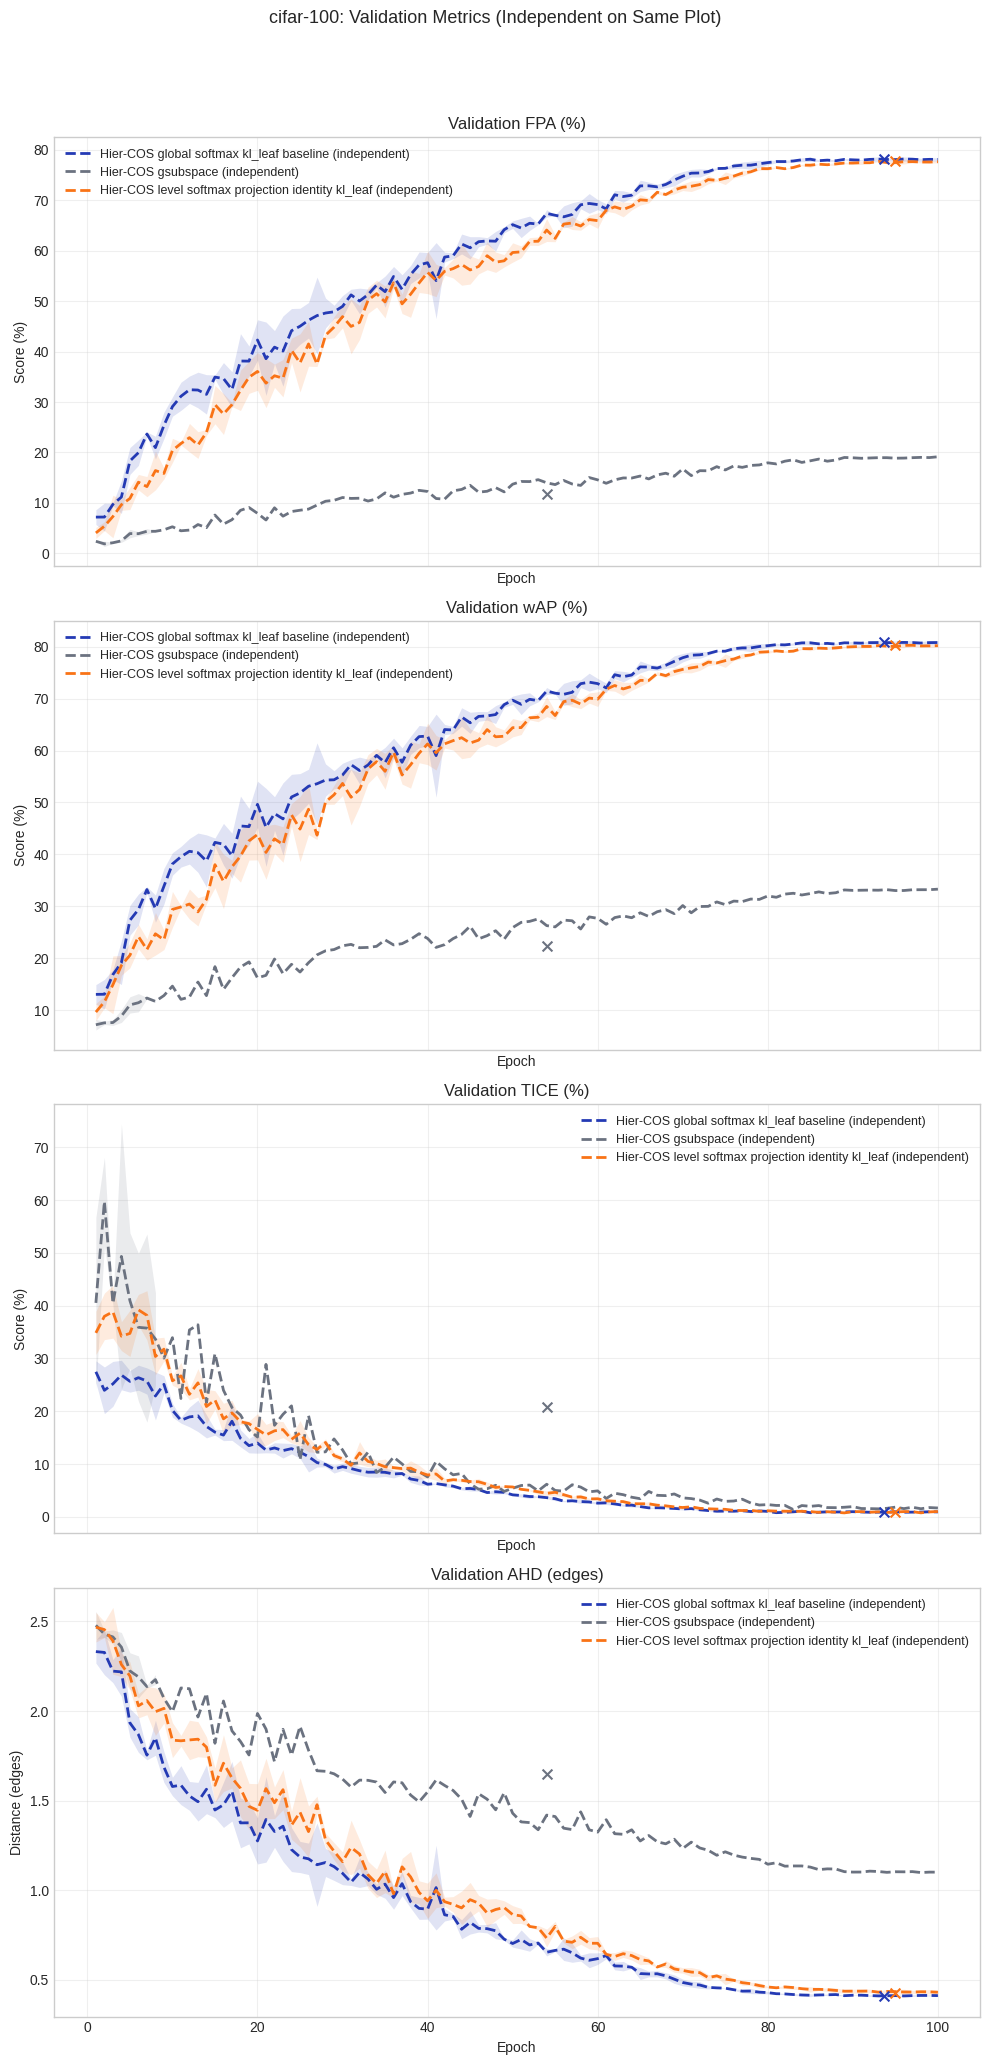

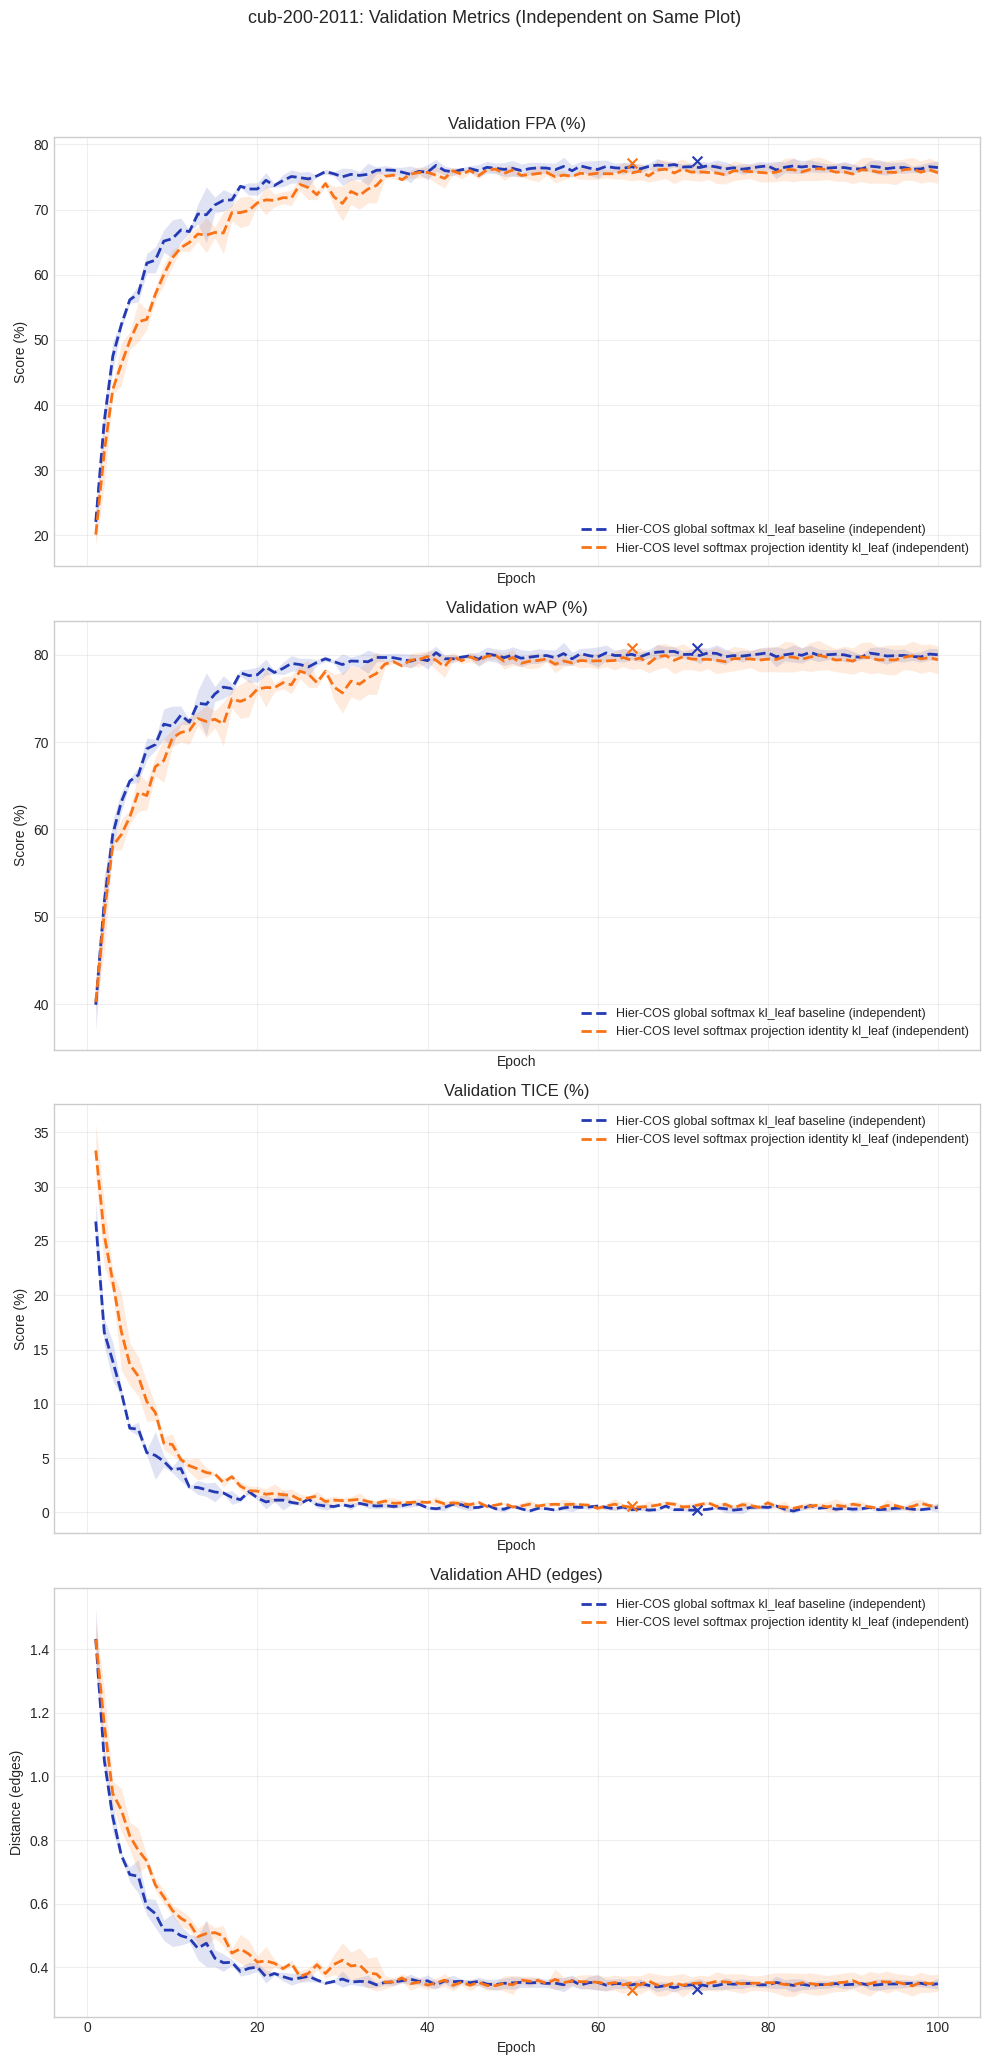

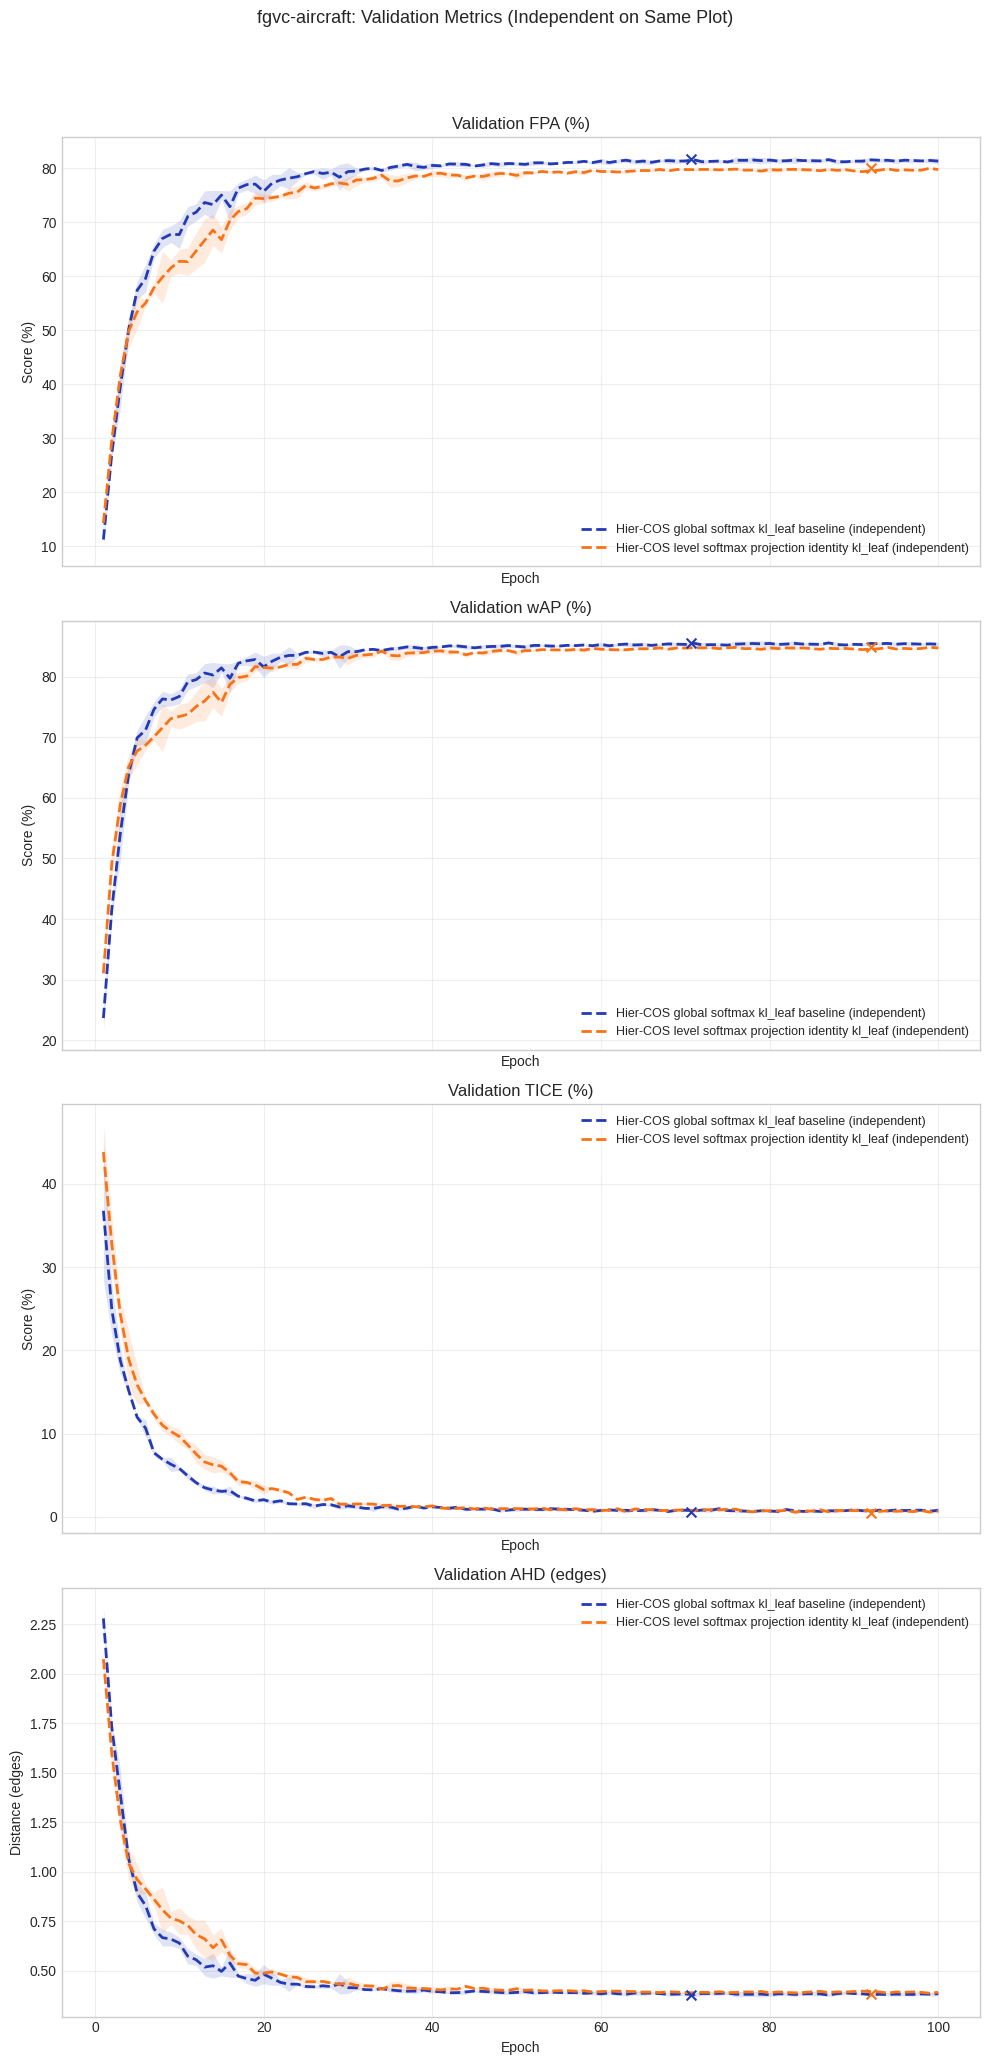

In [4]:
analysis.plot_validation_curves()


Interpretation note:
- For `FPA` and `wAP`, higher is better; for `TICE`, lower is better.
- Compare solid vs dashed lines of the same color to isolate hierarchy-enforcement effects for one run.
- Compare colors at the same line style to compare runs under the same decoding mode.

## Projection Diagnostics (If Available)

This section visualizes projection diagnostics logged in `val_metrics` and `train_metrics` (when available):
- `proj_constraint_alpha`, `proj_constraint_strength`, `proj_temperature`, `proj_mode_intrinsic_soft`

For standard Hier-COS runs these keys may be absent; in that case the section prints a per-dataset skip message.


In [5]:
analysis.plot_projection_diagnostics()


[cifar-100] No projection diagnostics found in selected runs.
[cub-200-2011] No projection diagnostics found in selected runs.
[fgvc-aircraft] No projection diagnostics found in selected runs.


## Training Loss Comparison

This section compares aggregate losses (`total`, `ce`, `reg`, and exact `kl` for `kl_reg`) and exact weighted per-level objectives (`loss_level_*`, when available).


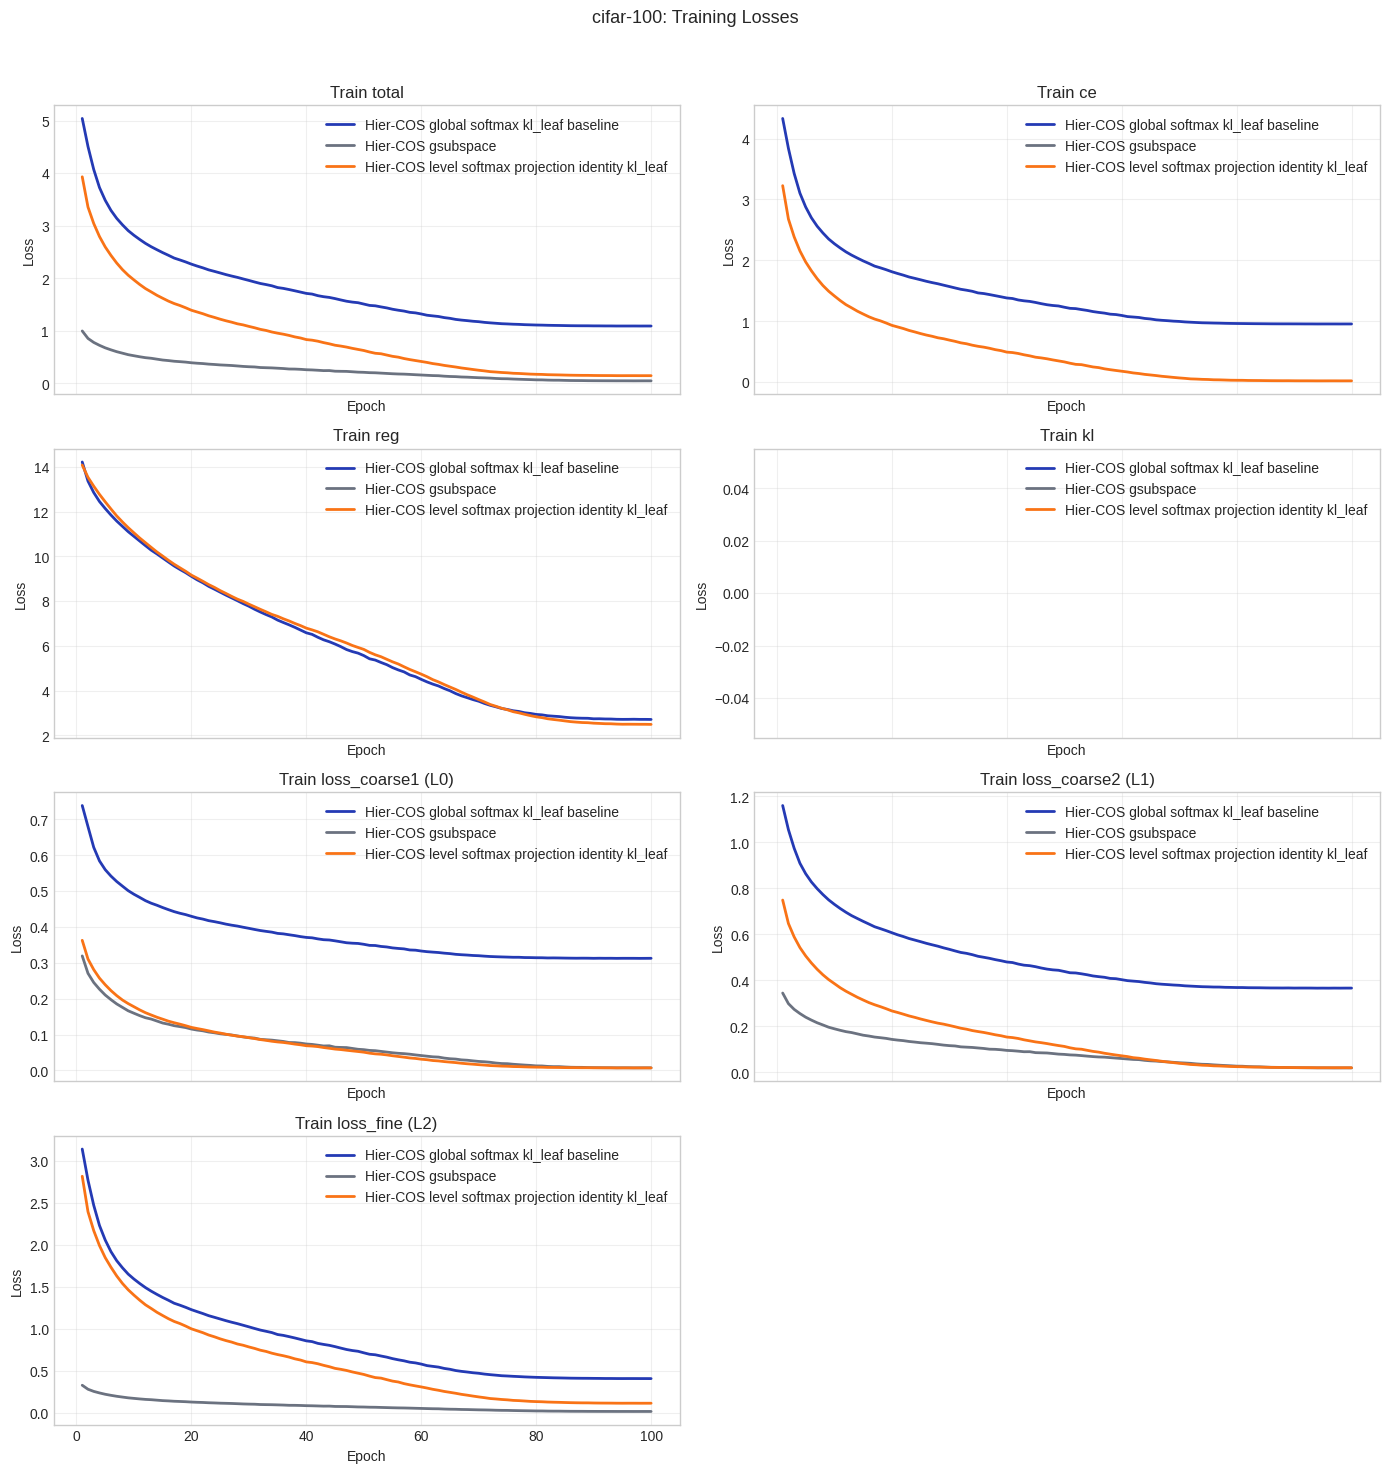

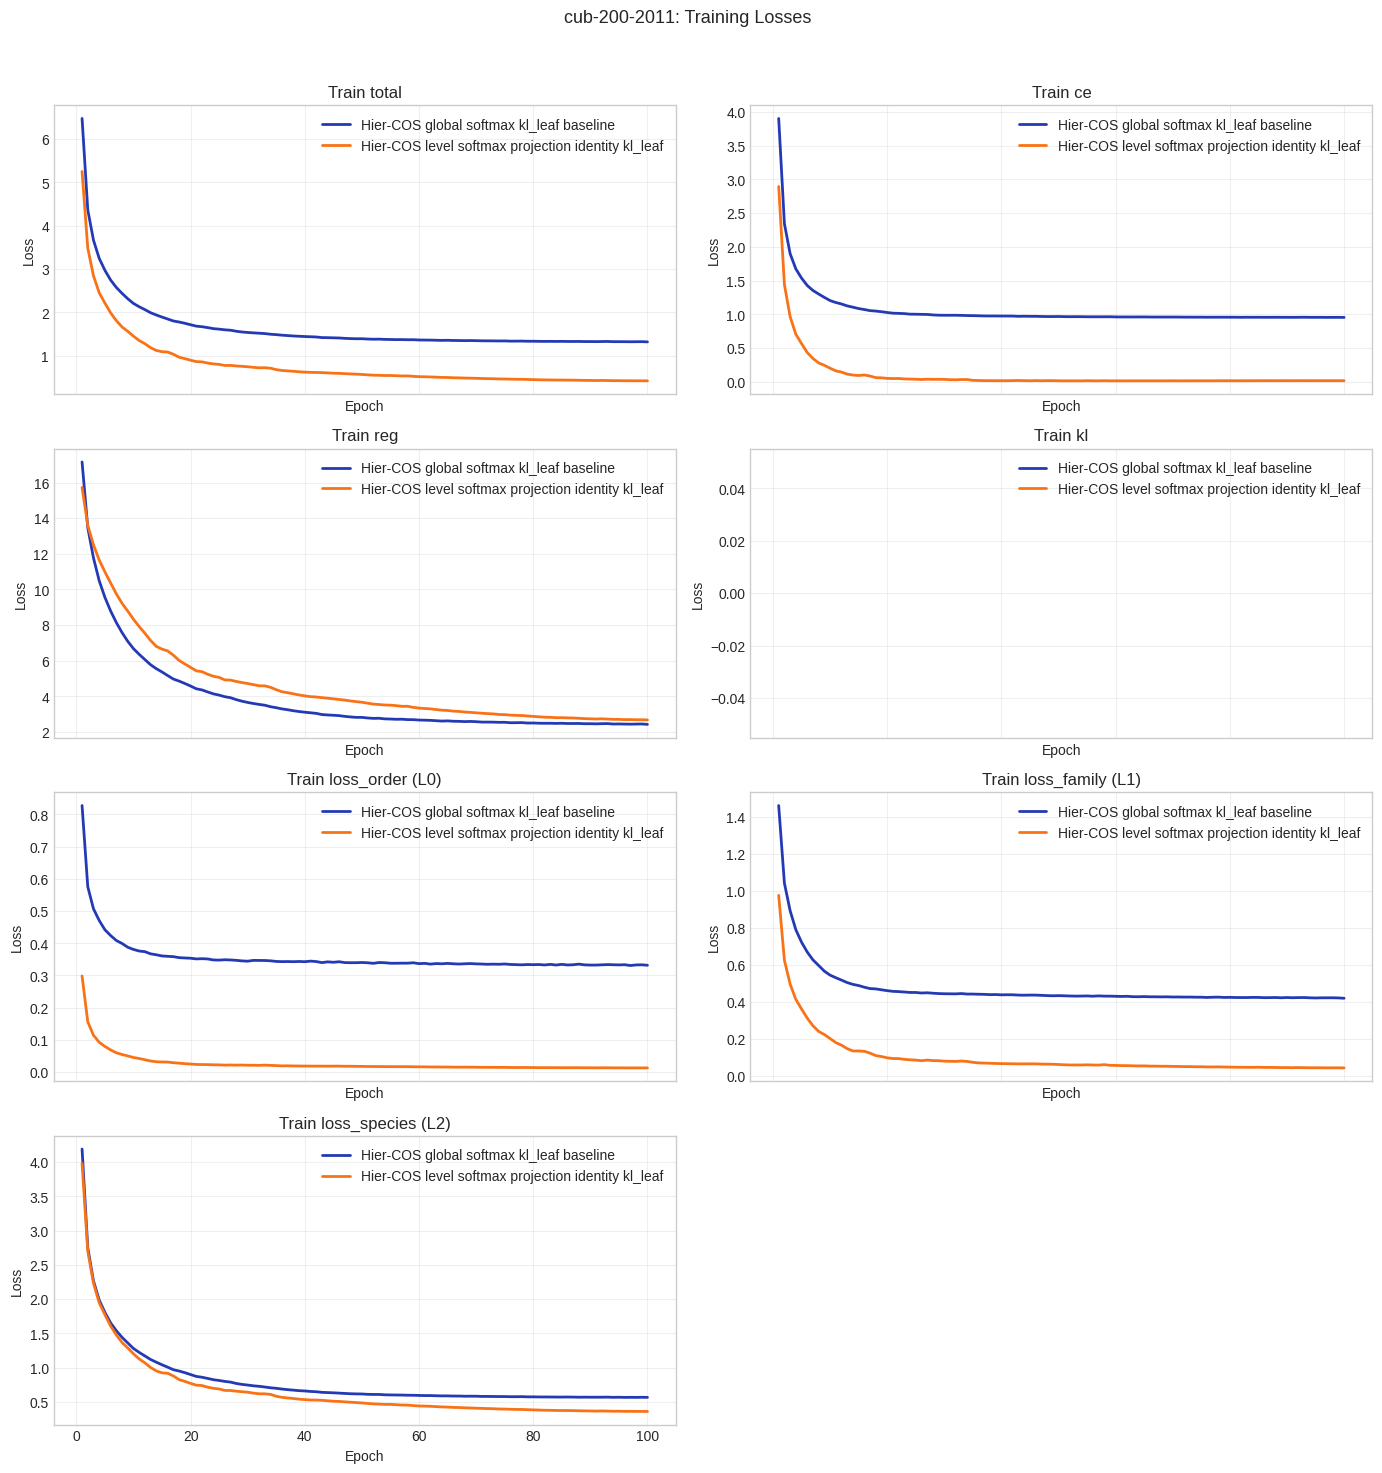

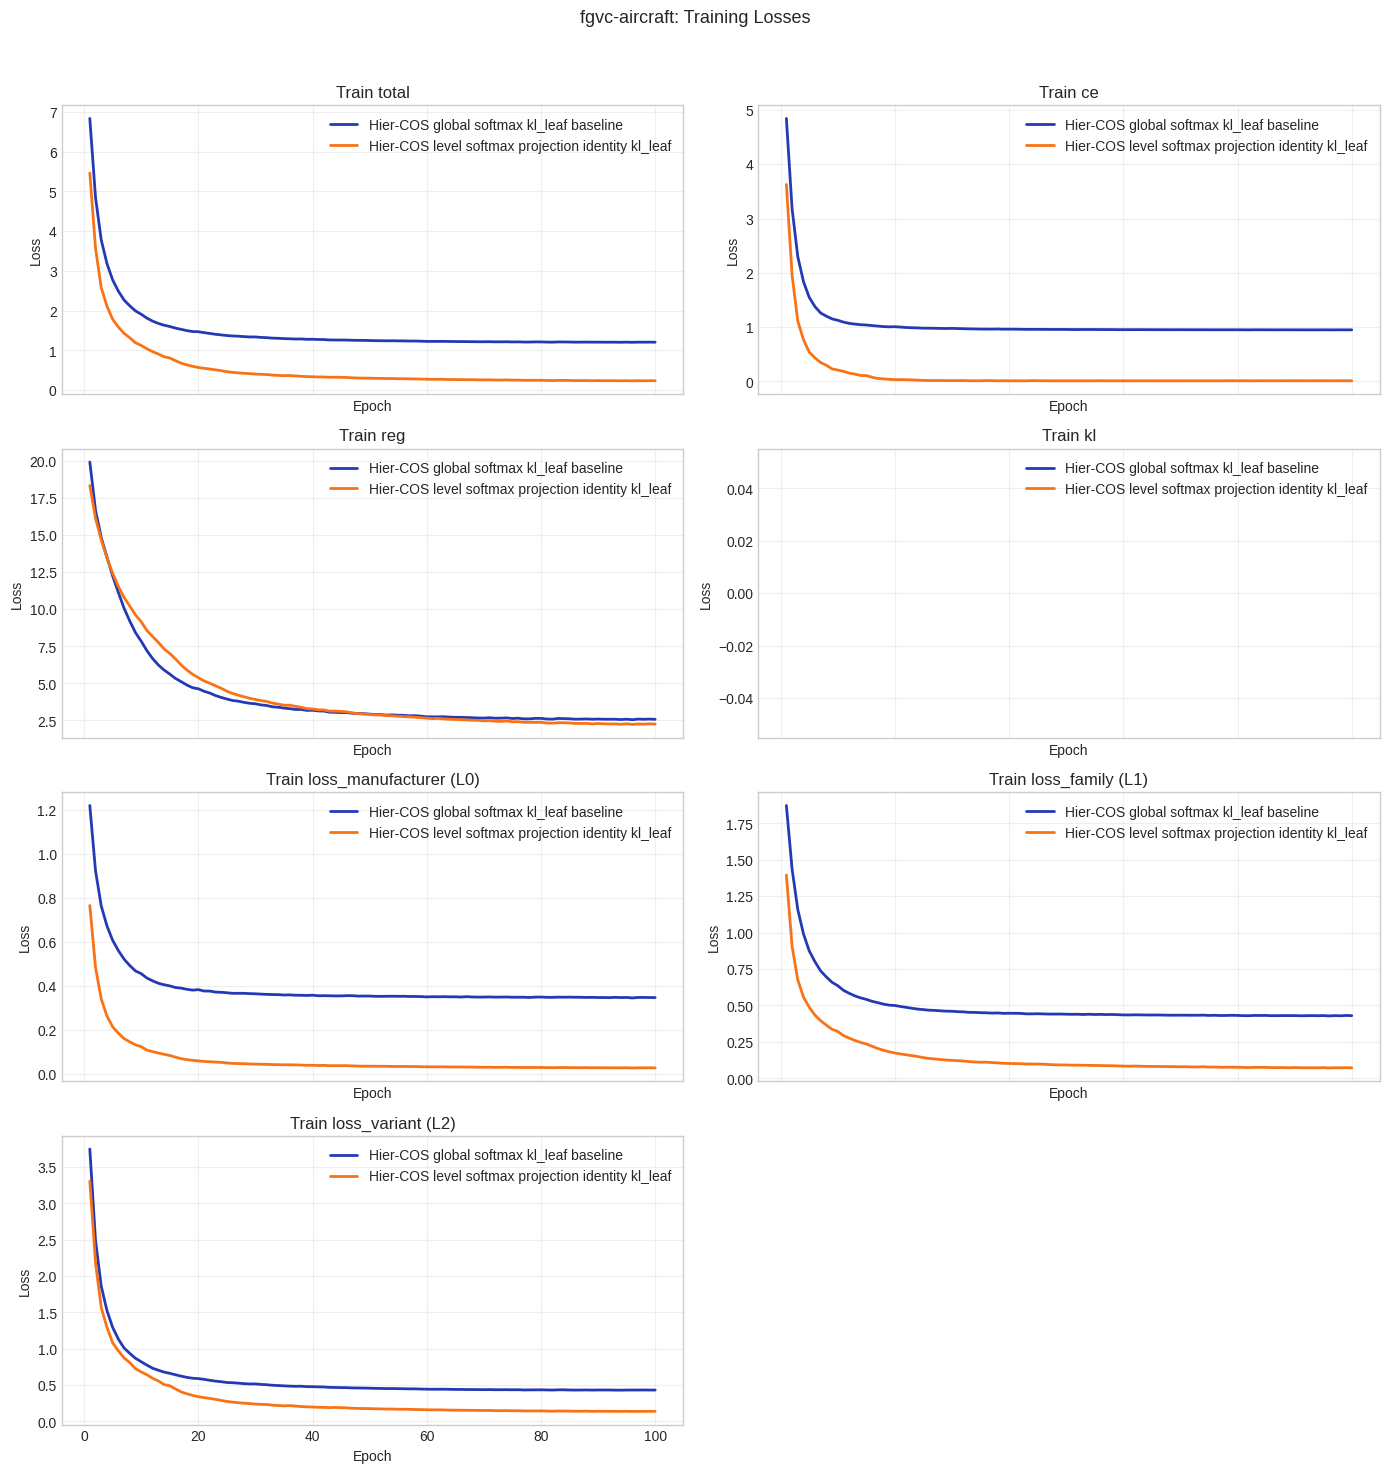

In [6]:
analysis.plot_training_losses(aggregate_loss_keys=['total', 'ce', 'reg', 'kl'])


Interpretation note:
- Lower is better for all loss curves.
- Compare `total` first for optimization behavior, then `loss_level_*` to see where depth-specific training differs.
- If one run has consistently lower shallow-level loss but much higher deep-level loss, expect weaker fine-grained accuracy and path metrics.

## Per-Run Per-Level Training Losses (Per Dataset)

Interpretation note:
- Each chart corresponds to one selected run in its dataset section.
- Lines in the same chart are all available `loss_level_*` training losses (lower is better).



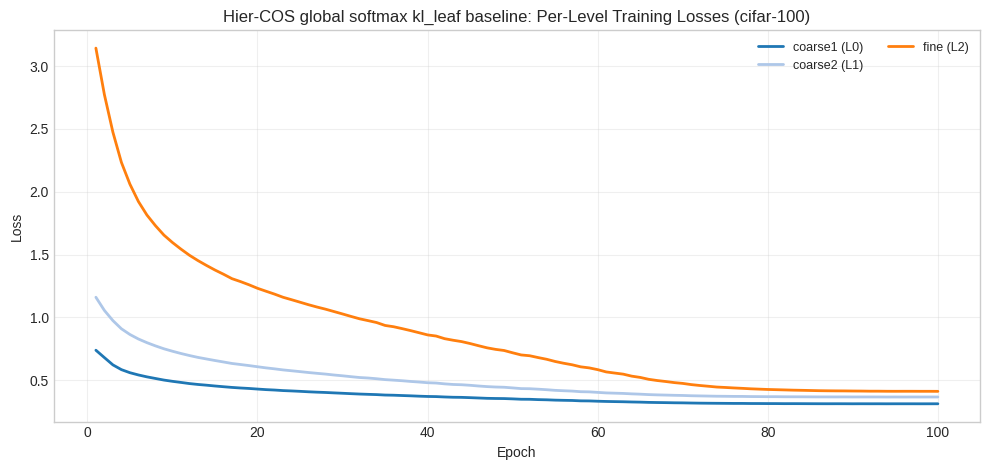

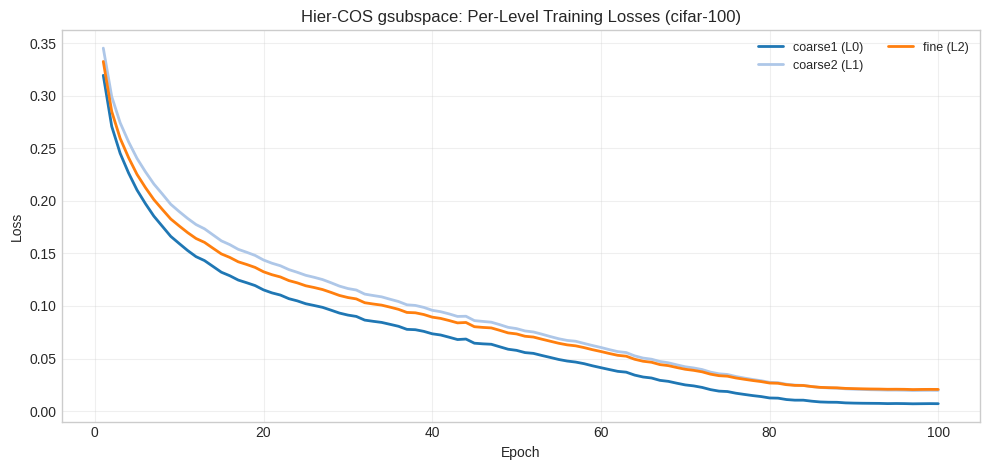

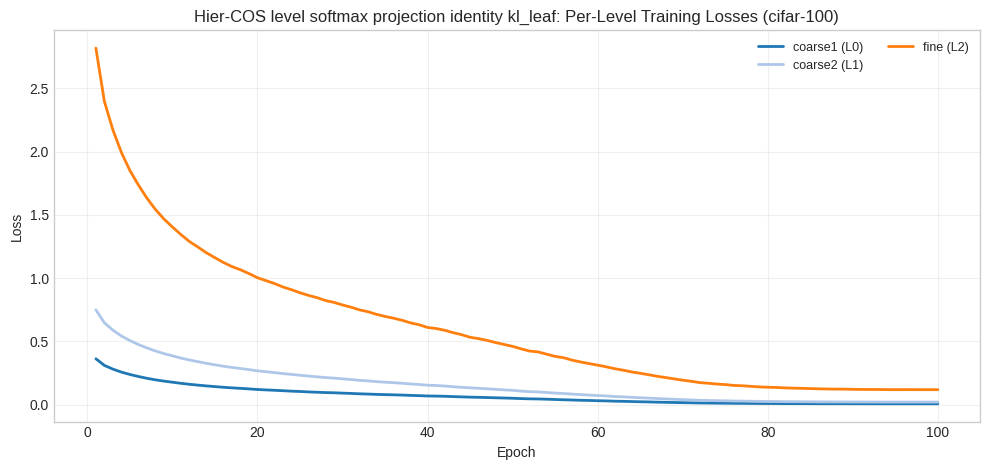

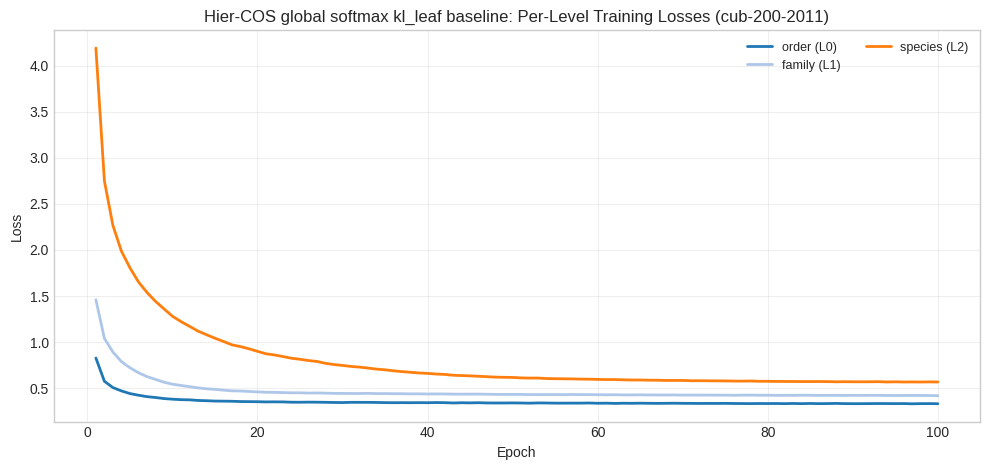

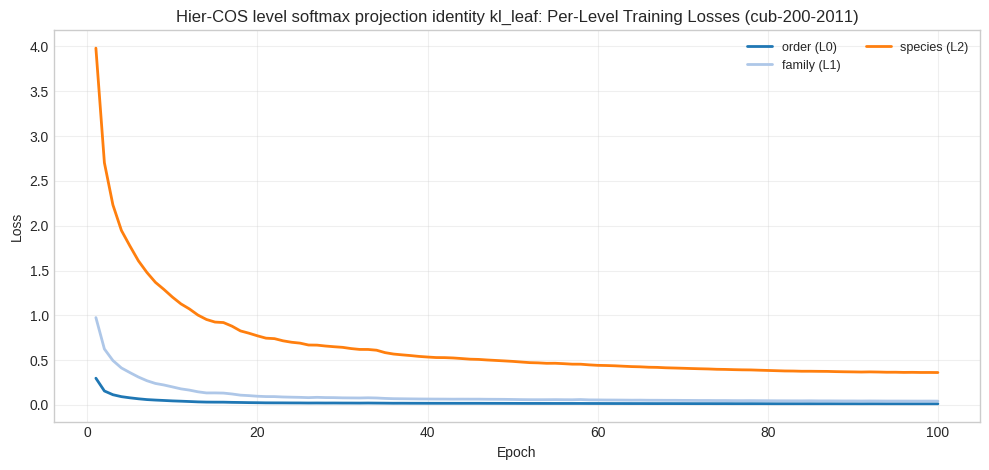

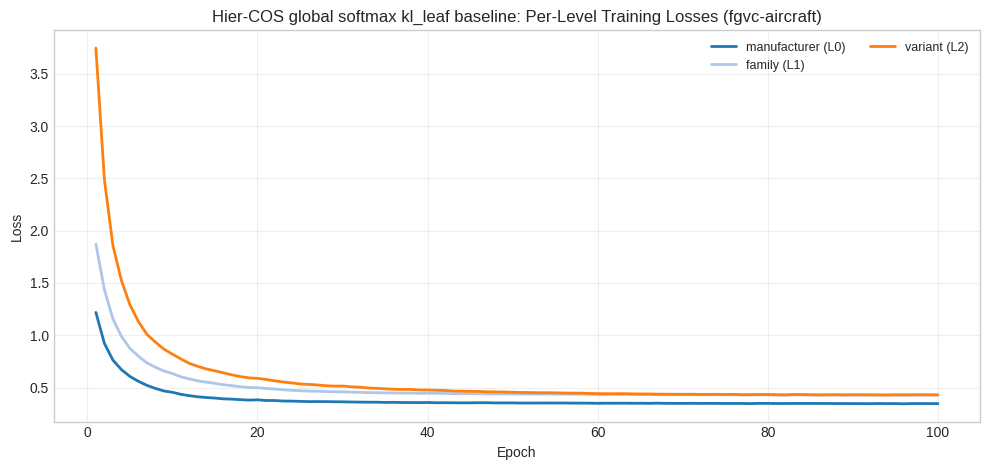

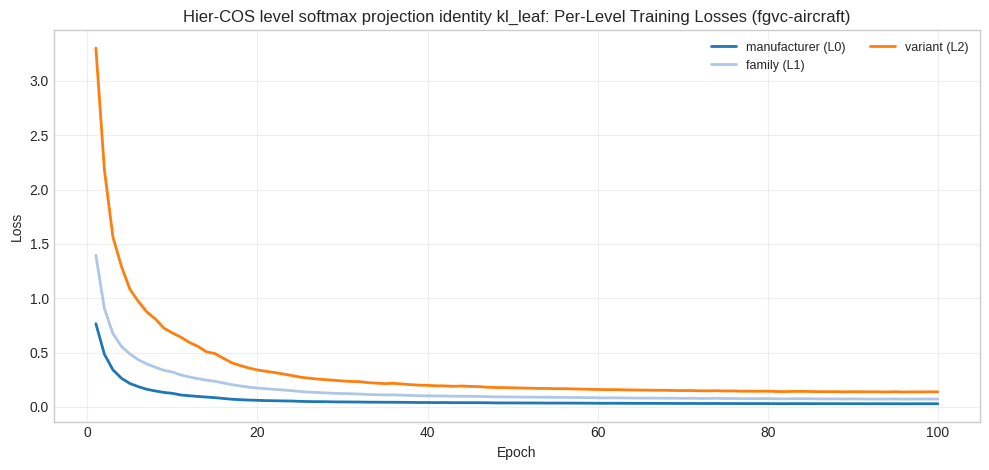

In [7]:
analysis.plot_per_run_per_level_training_losses()


## Gradient Diagnostics (Train)

This section visualizes trunk-based gradient/parameter metrics and optional projection diagnostics stored in `train_metrics` for each epoch.

For Hier-COS, many of these metrics are available only in CE/diagnostic-focused runs. If unavailable, corresponding plots are skipped automatically.


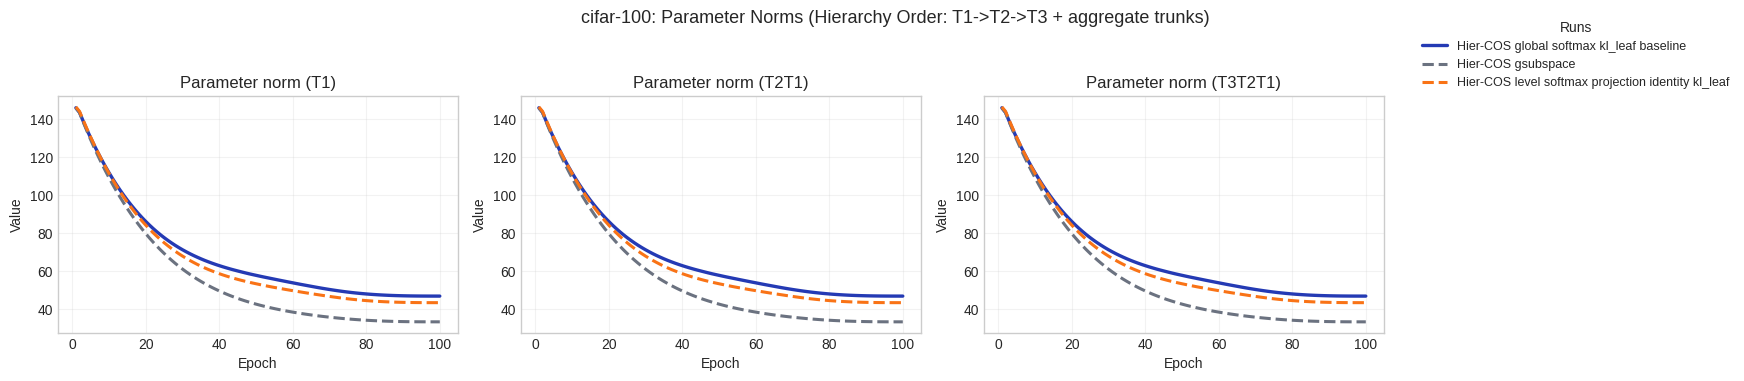

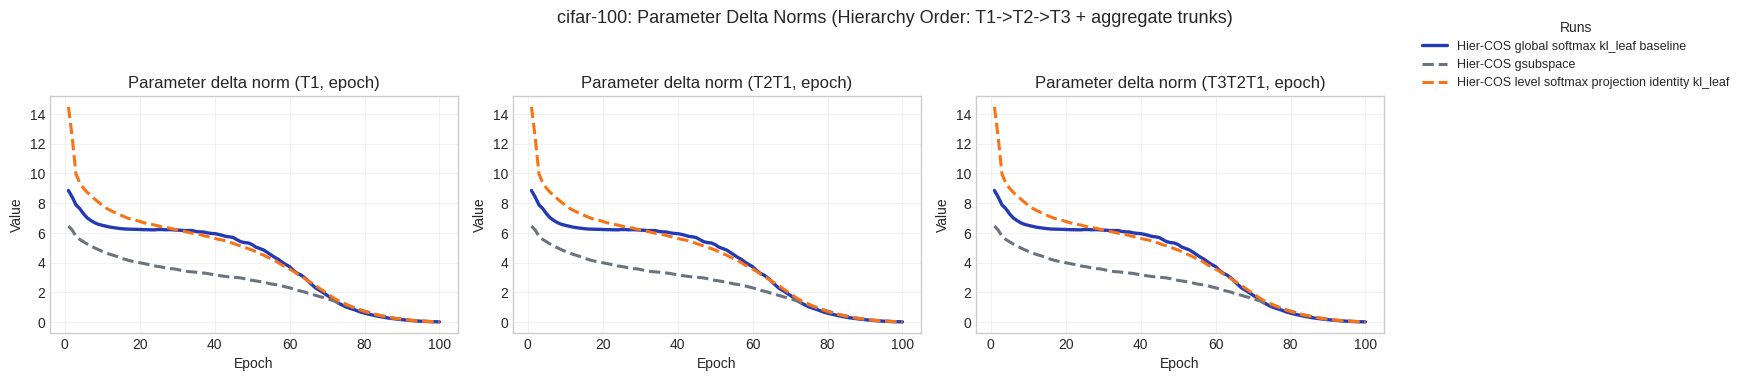

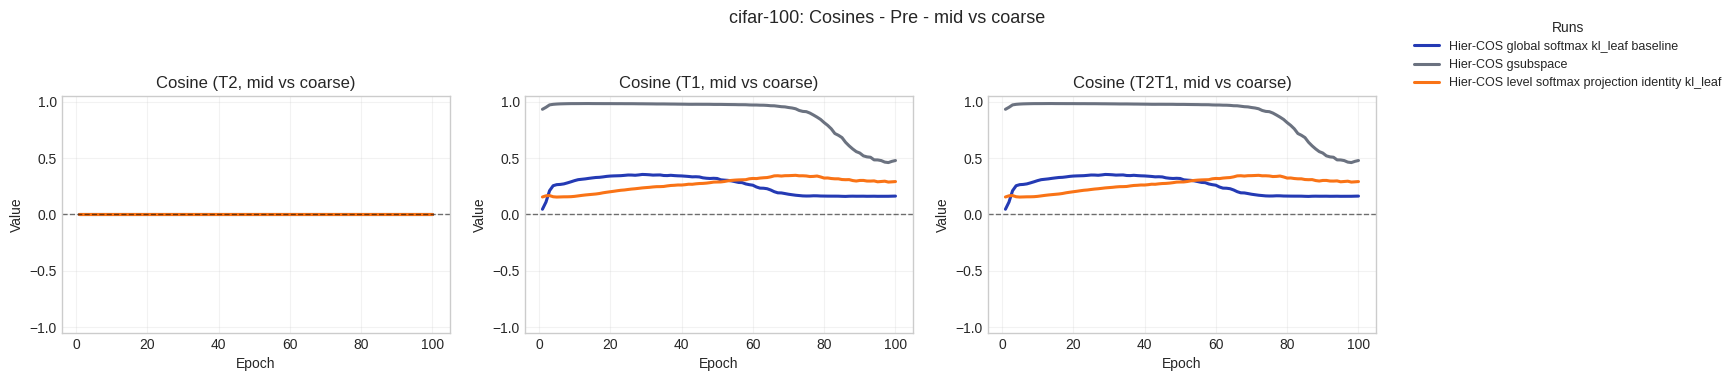

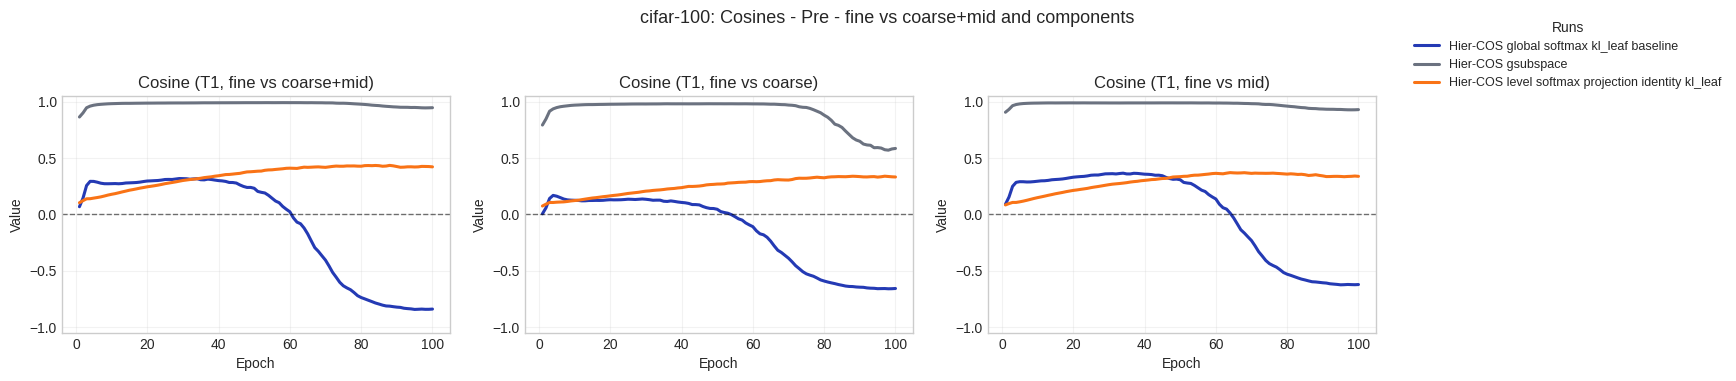

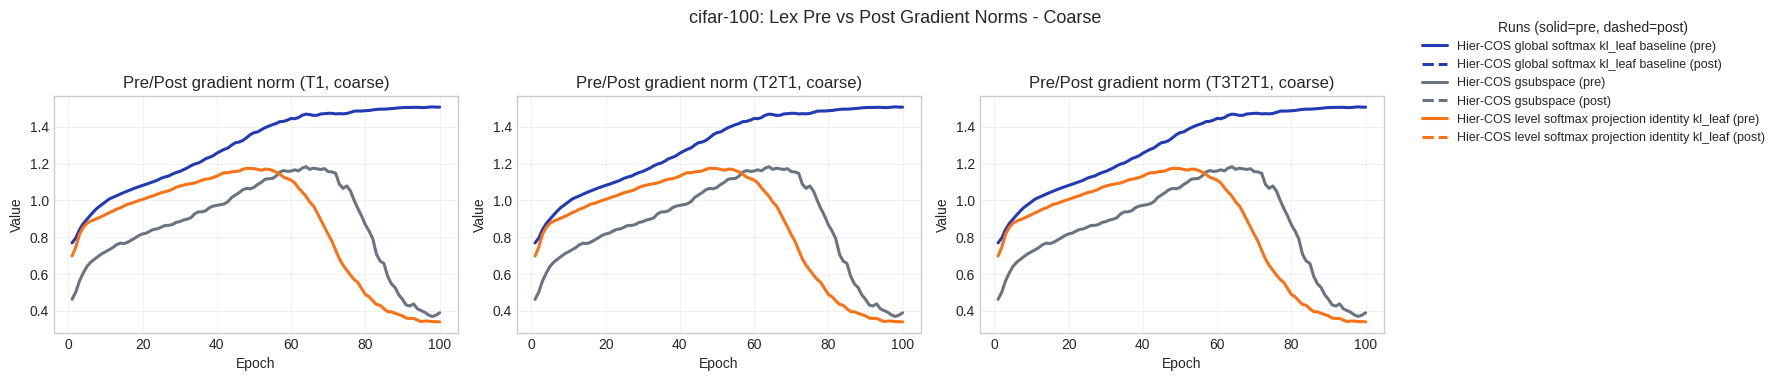

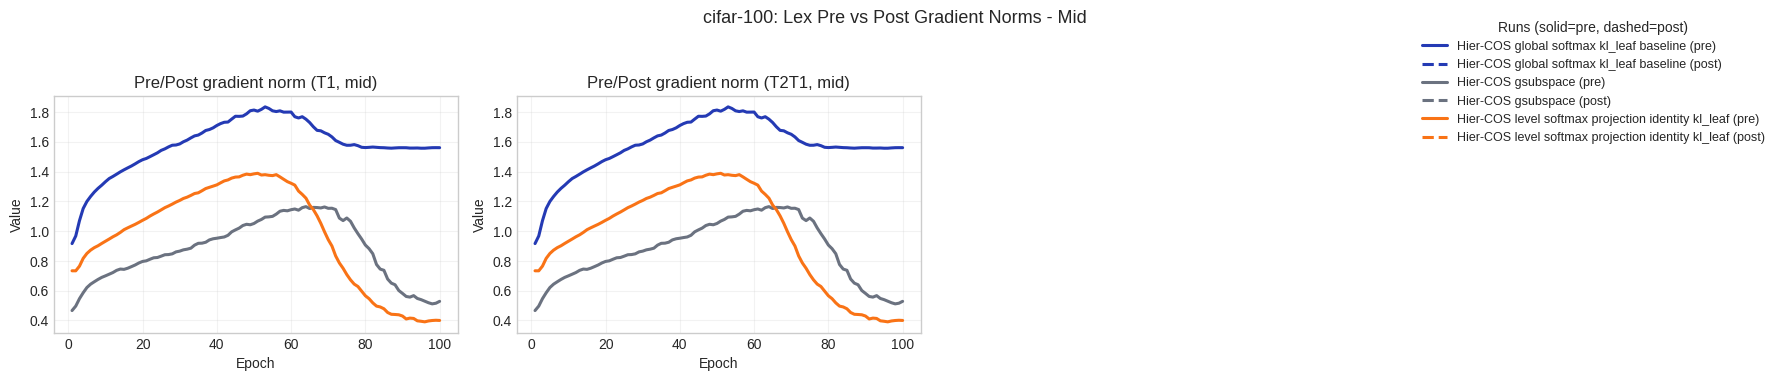

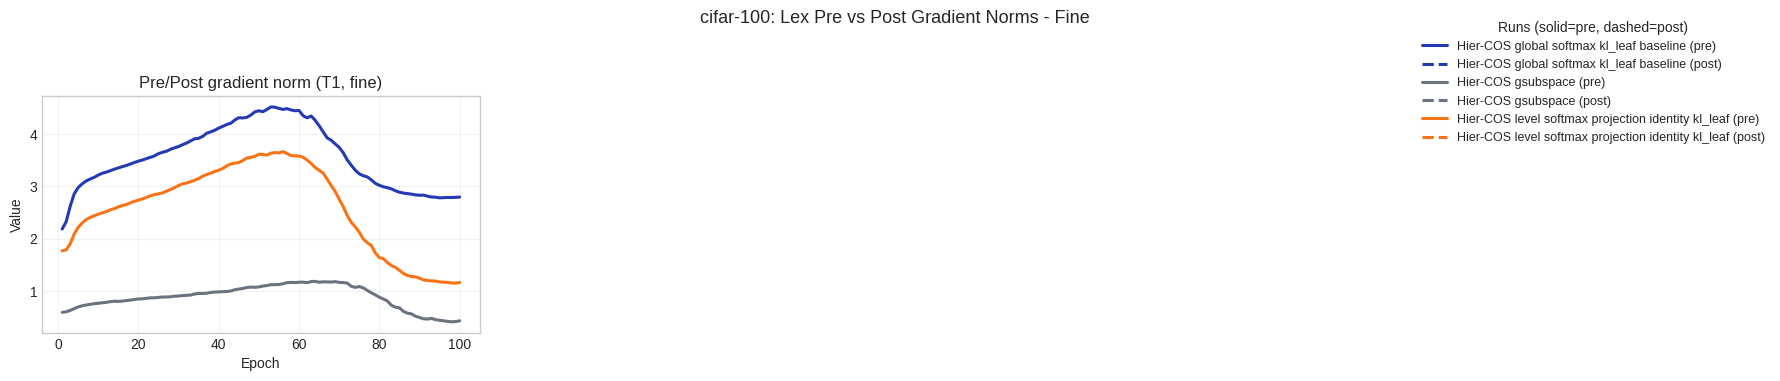

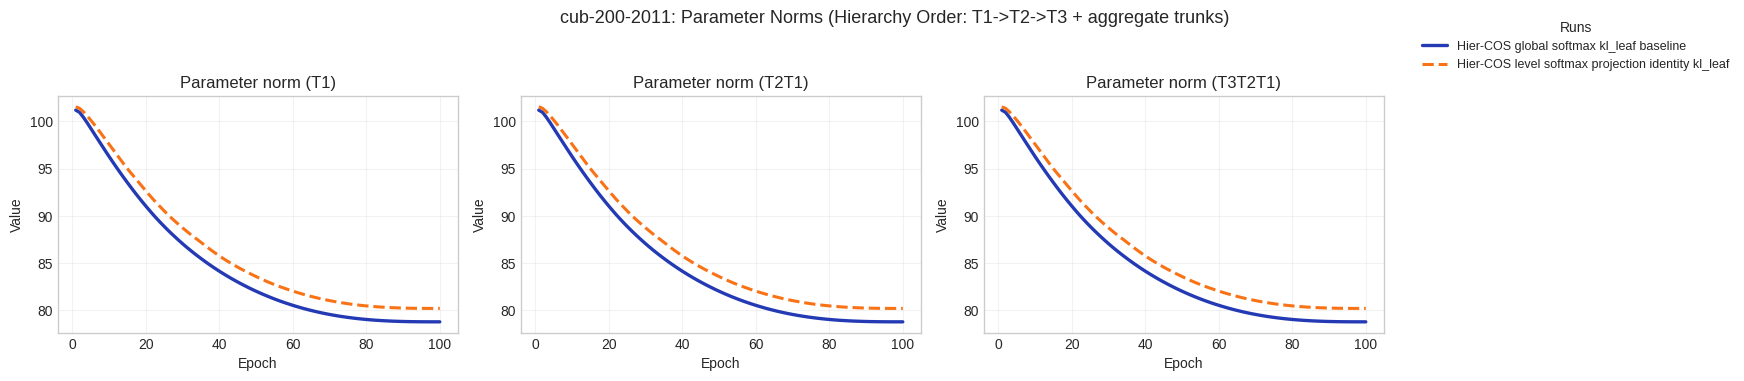

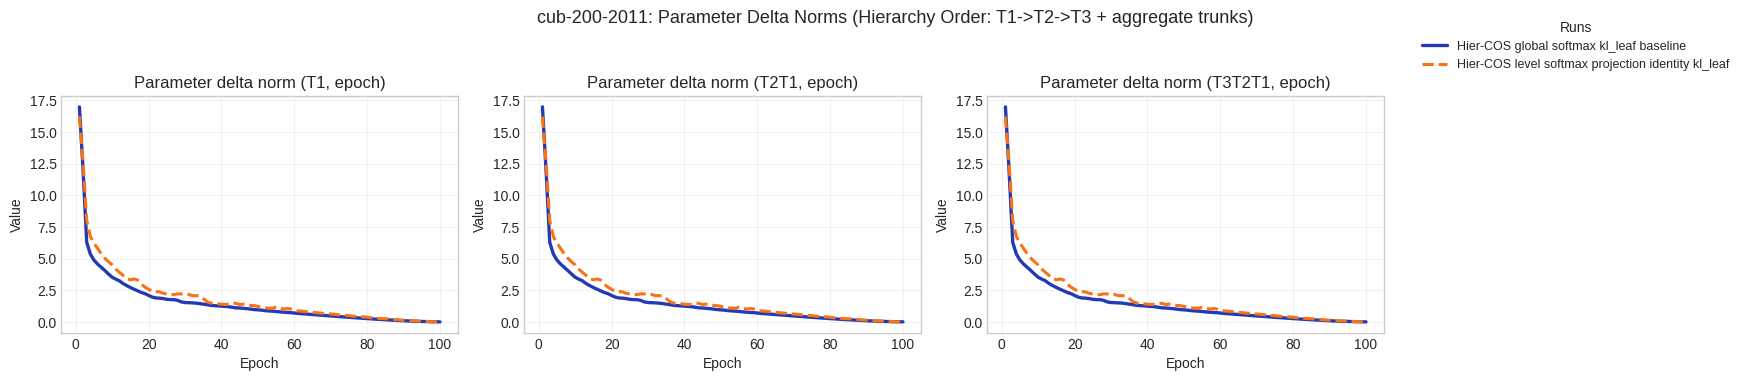

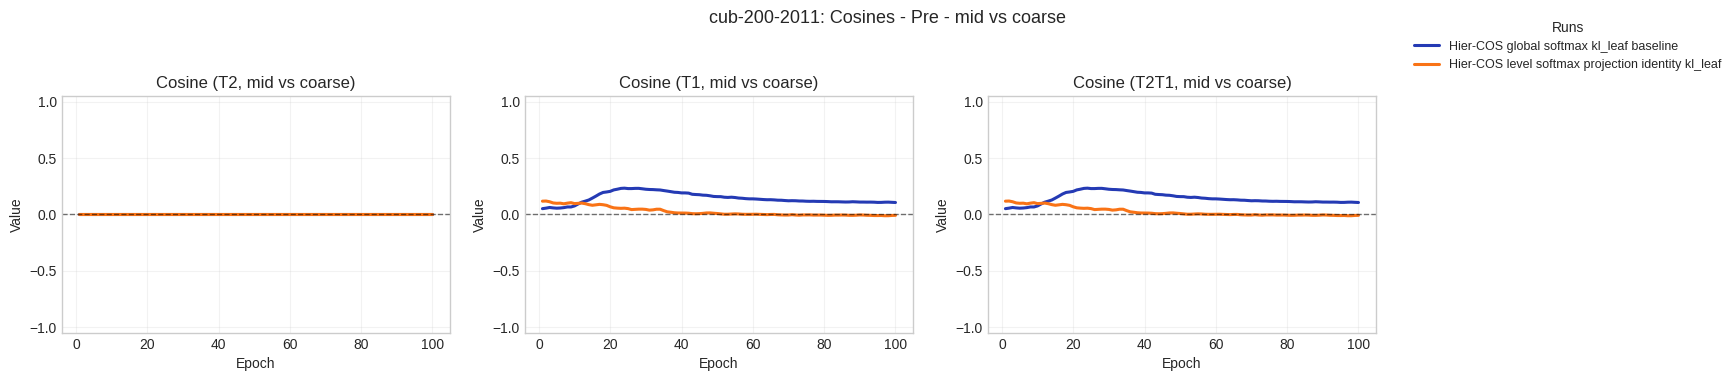

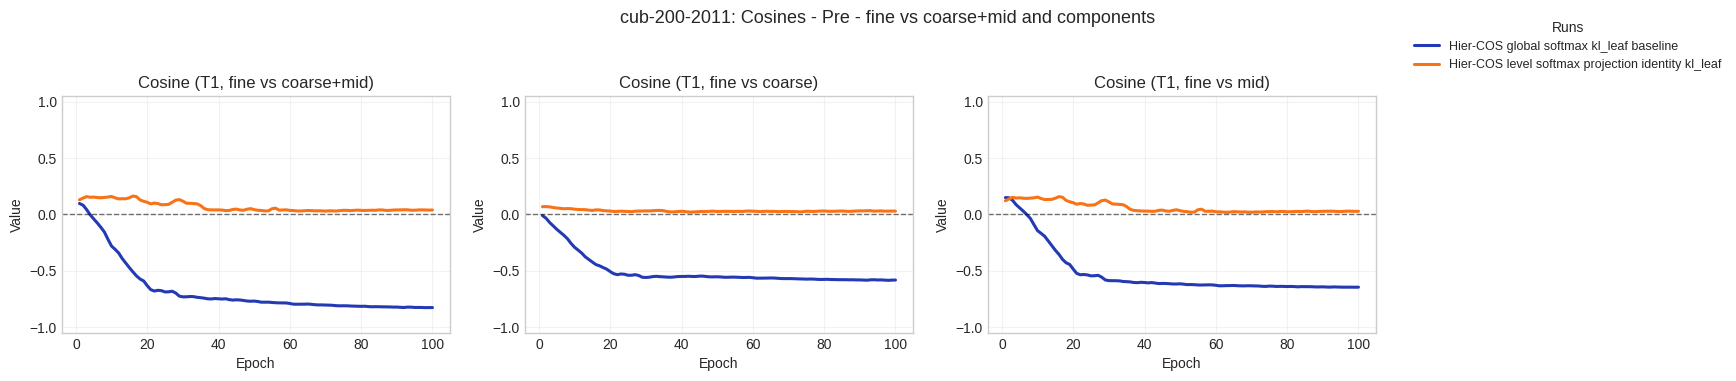

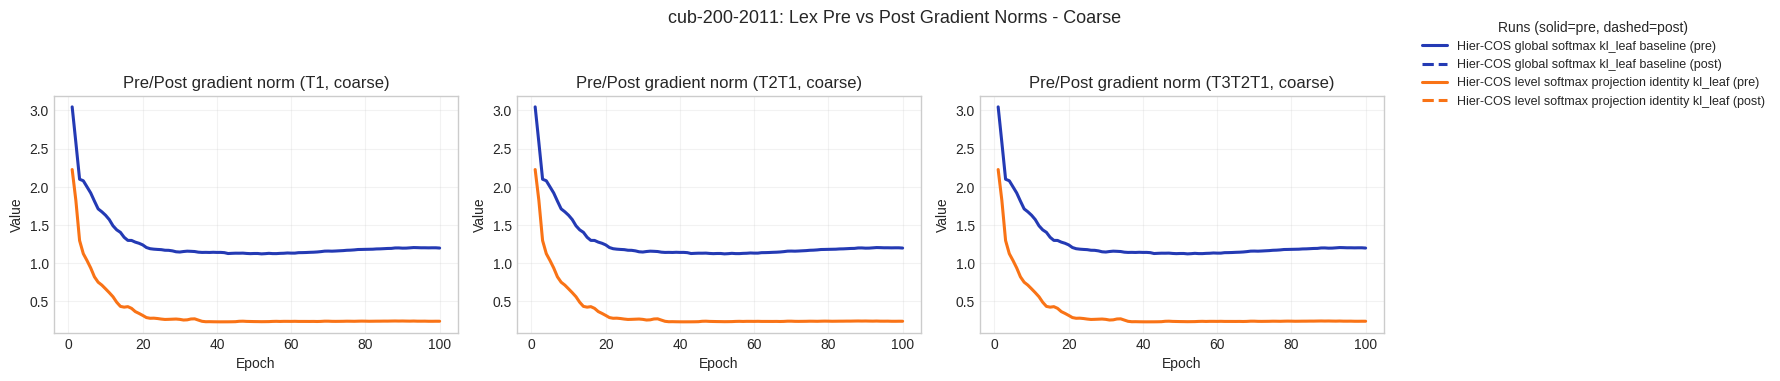

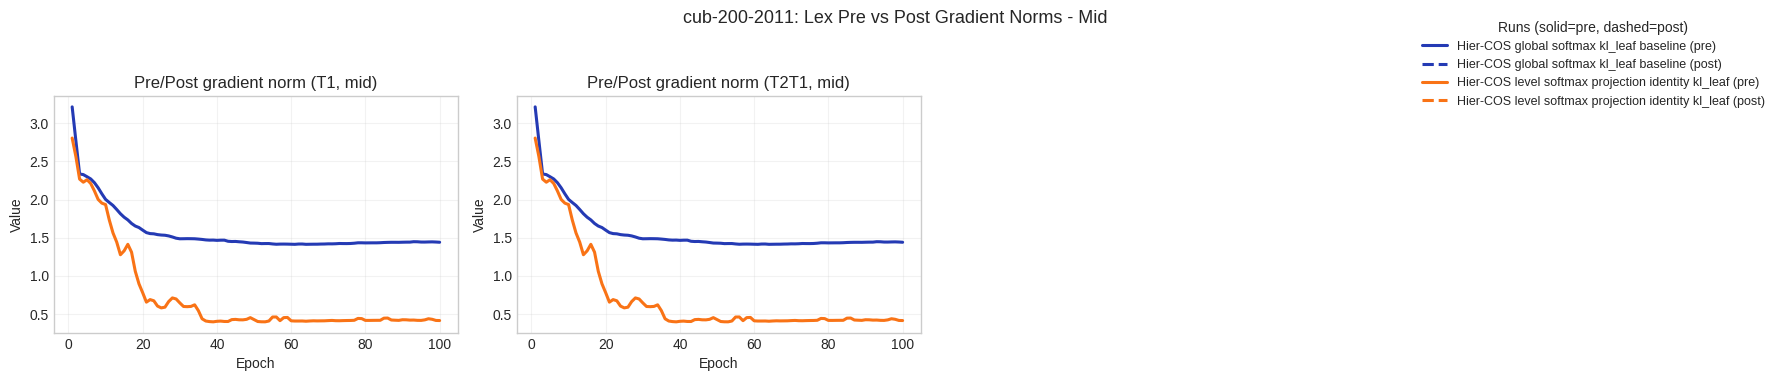

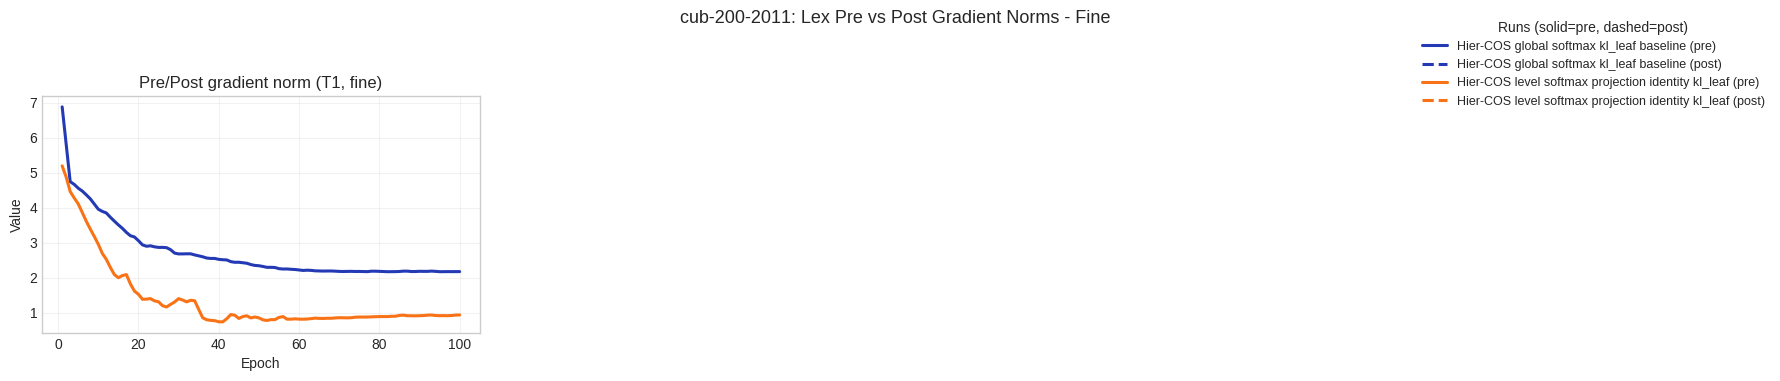

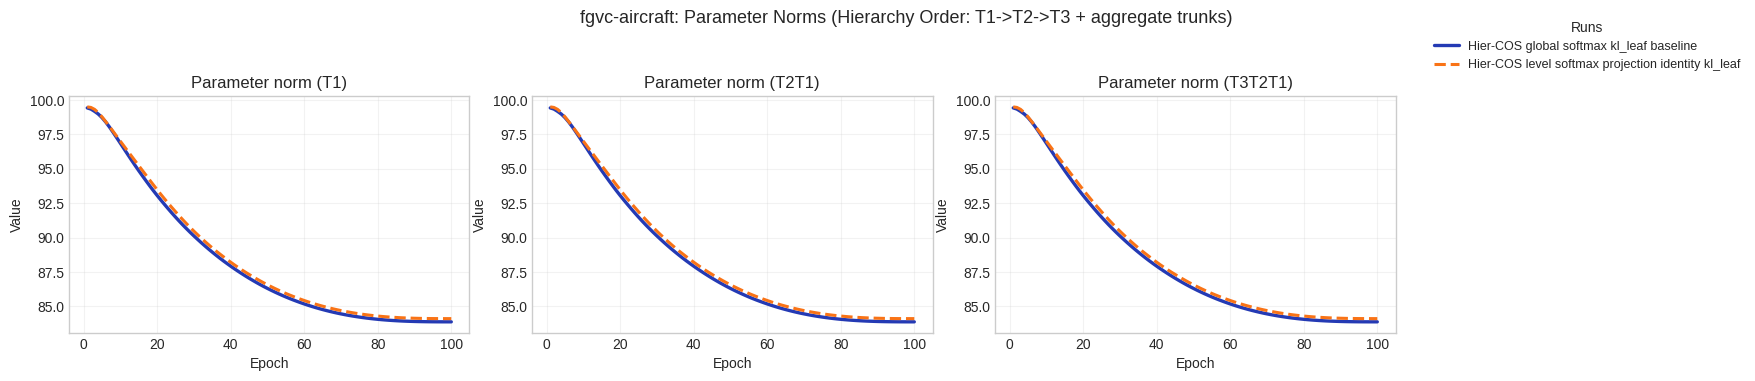

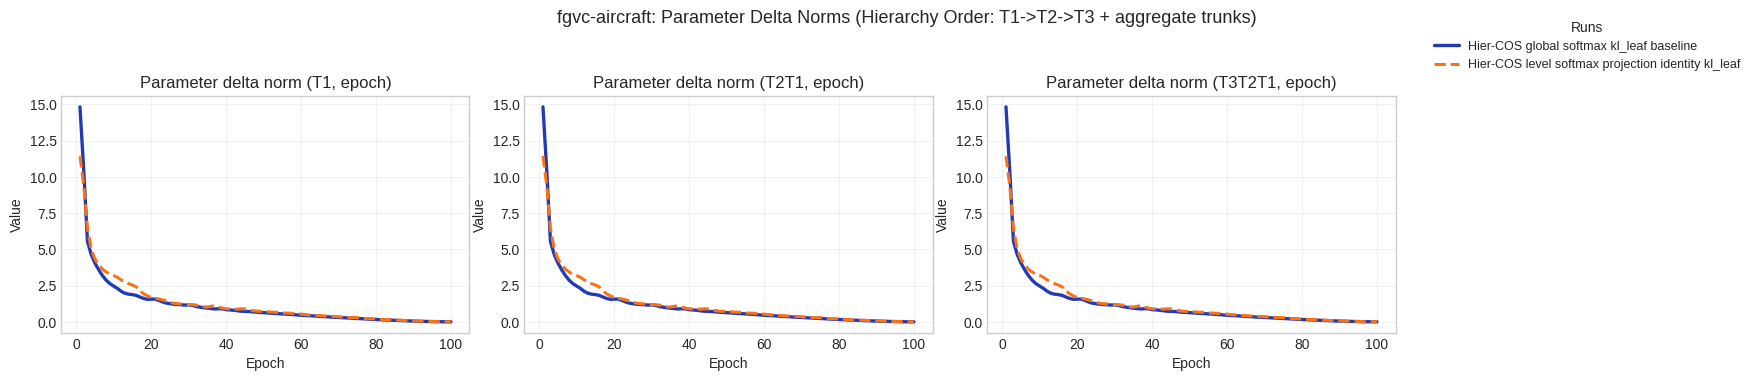

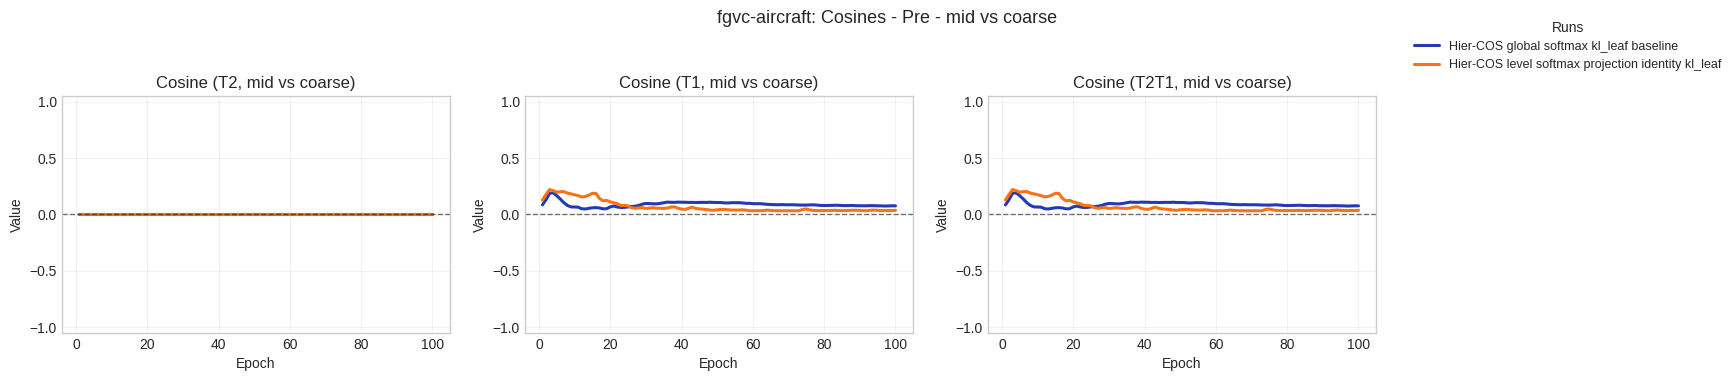

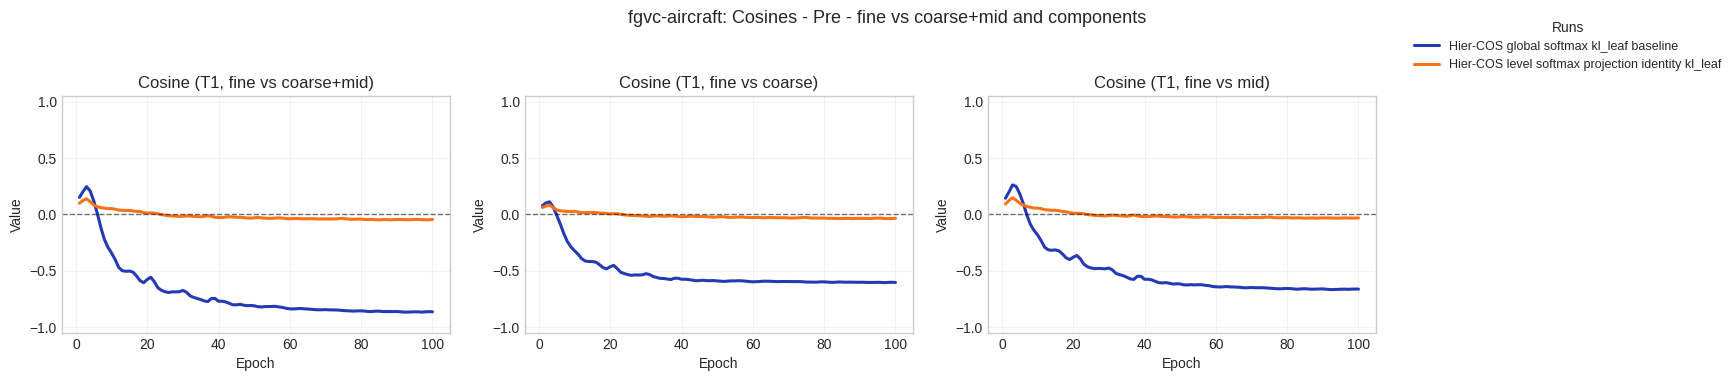

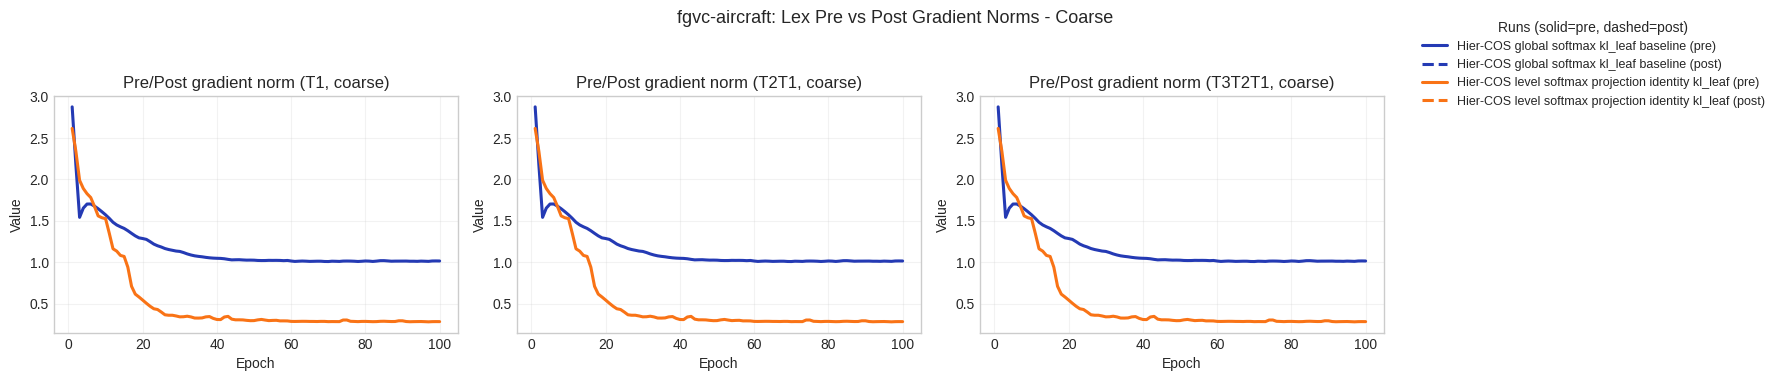

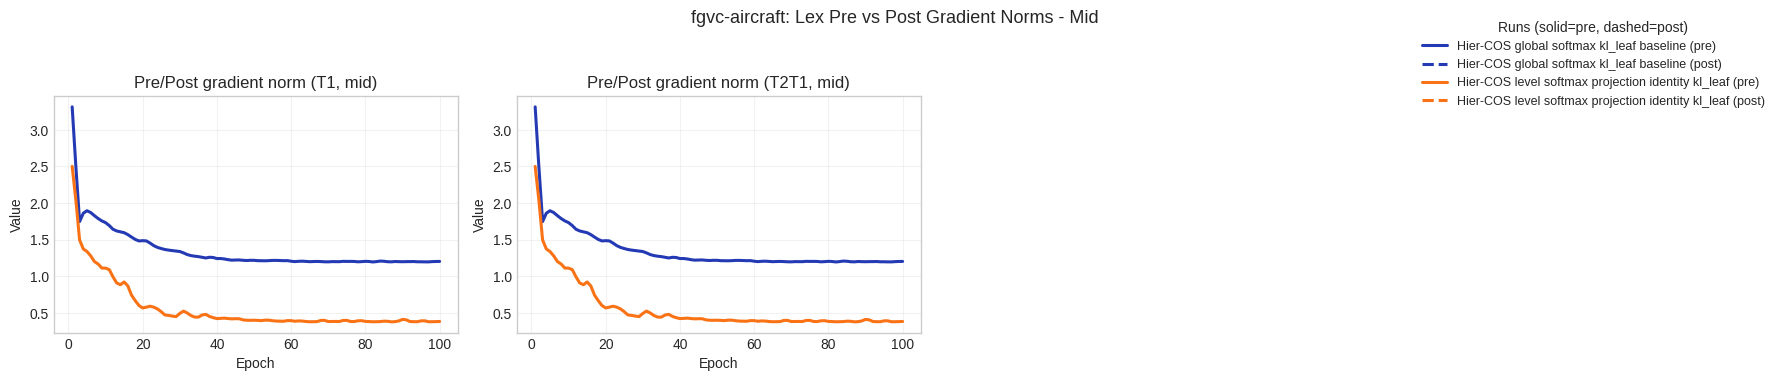

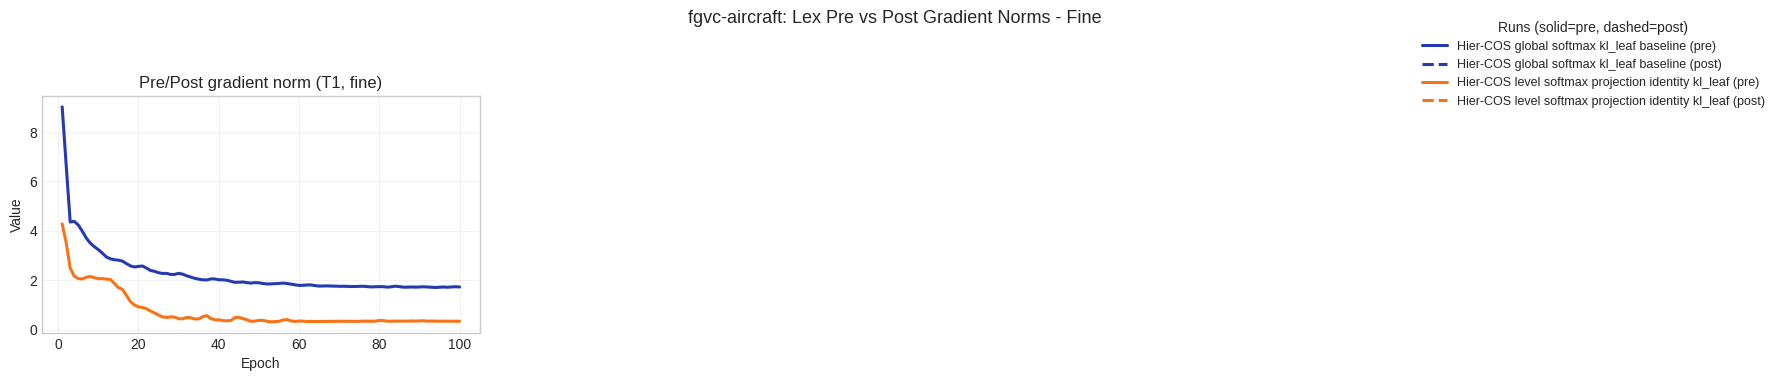

In [8]:
GRAD_SMOOTH_WINDOW = 2
SHOW_RAW_OVERLAY = False
RAW_ALPHA = 0.12
N_COLS = 3
LOG_SCALE_FOR_NORMS = False
AX_WIDTH = 6.0
AX_HEIGHT = 3.8
LEGEND_GUTTER_RATIO = 0.78
LEGEND_MAX_ROWS_PER_COL = 10

analysis.plot_gradient_diagnostics(
    smooth_window=GRAD_SMOOTH_WINDOW,
    show_raw_overlay=SHOW_RAW_OVERLAY,
    raw_alpha=RAW_ALPHA,
    n_cols=N_COLS,
    log_scale_for_norms=LOG_SCALE_FOR_NORMS,
    ax_width=AX_WIDTH,
    ax_height=AX_HEIGHT,
    legend_gutter_ratio=LEGEND_GUTTER_RATIO,
    legend_max_rows_per_col=LEGEND_MAX_ROWS_PER_COL,
)


Interpretation note:

- Large spikes in gradient norms indicate unstable update pressure for that subset/level path.
- If `grad_norm_t1_fine` collapses while `t1` coarse/mid stay high, fine supervision is not effectively reaching shared parameters.
- Negative cosine values indicate level conflict on the corresponding subset.
- `param_norm_*` is scale, `delta_param_norm_*` is per-epoch movement.
- In lex mode, projected cosines should move near 0 (orthogonality on the target mask).
- `post_projection_applied_* = 0` means the corresponding projection step was skipped for numerical safety.


## Per-Level Validation Accuracy (Top-Down and Independent)

Each level plot overlays both modes on the same axes:
- color = run
- line style = mode (`topdown` solid, `independent` dashed).

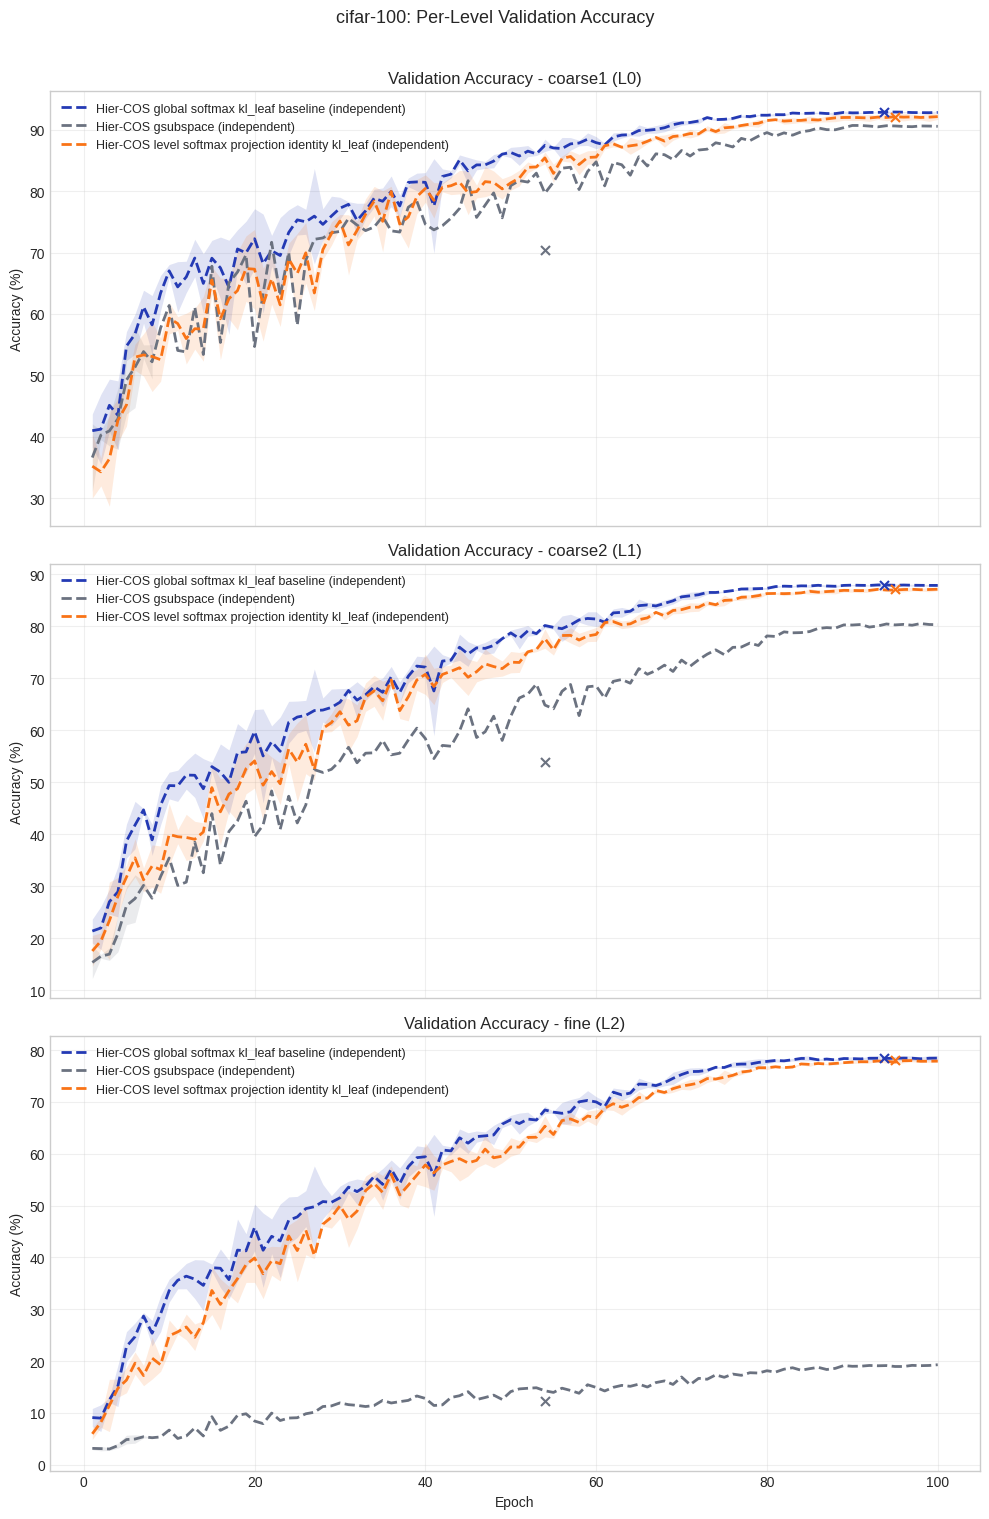

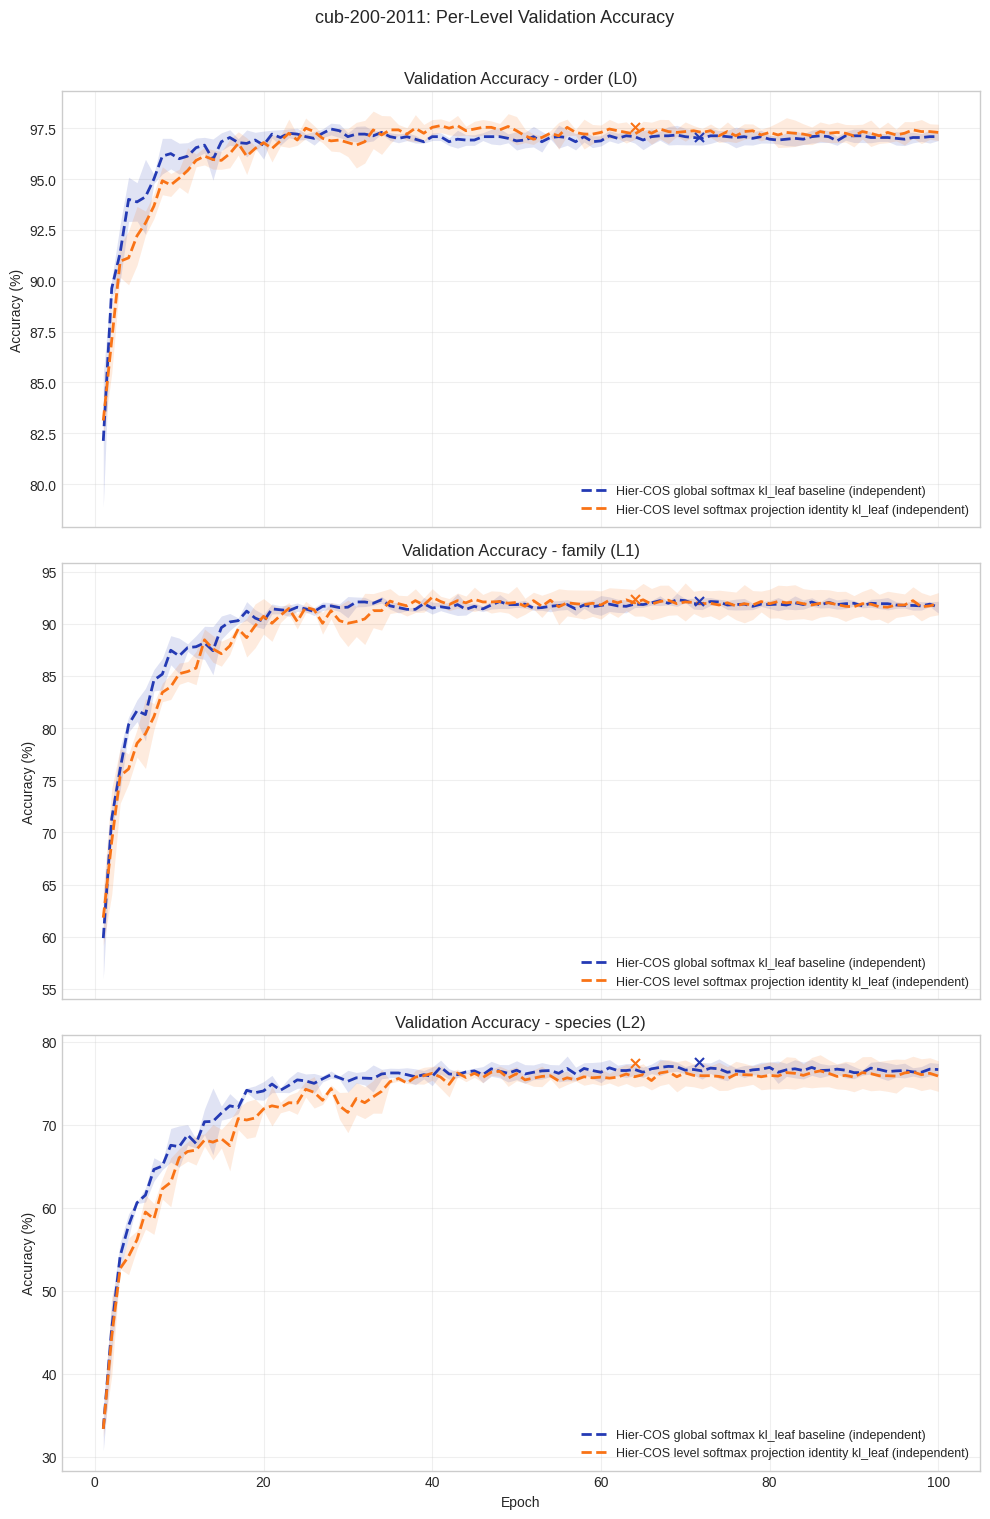

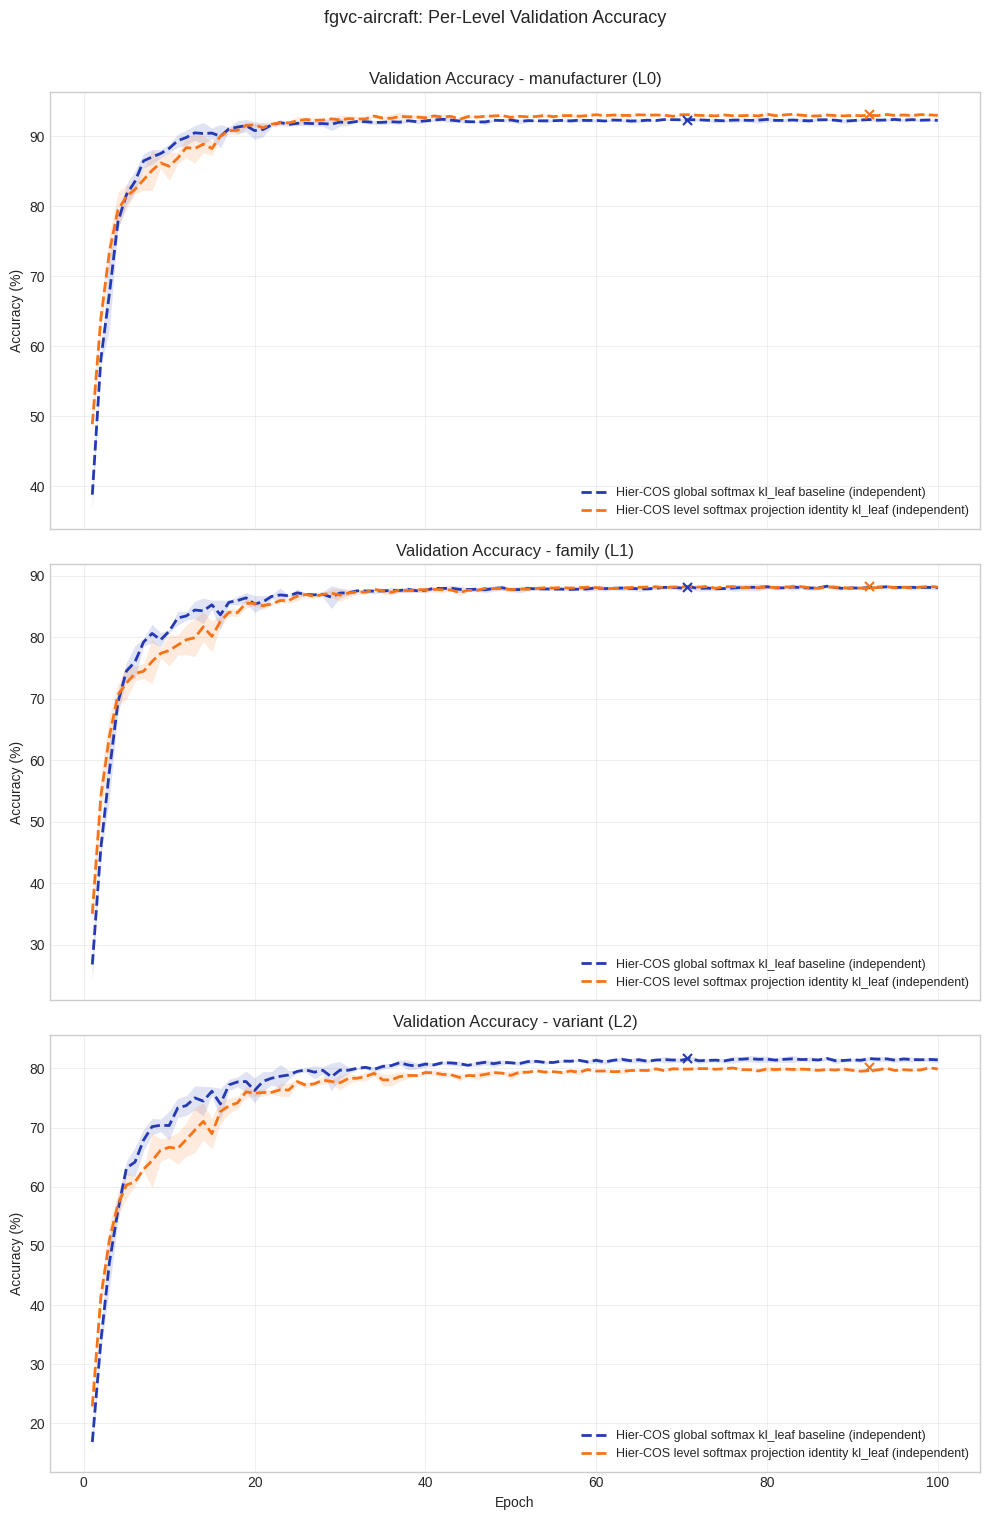

In [9]:
analysis.plot_per_level_validation_accuracy()

Interpretation note:
- In each subplot, solid vs dashed of the same color gives the top-down penalty/gain for that run.
- Across colors, you can compare runs within the same decoding mode by matching line style.
- Larger gaps at deeper levels usually have the strongest impact on final path metrics.

## Final Test Comparison Table

For each dataset, the table compares key test metrics for selected runs and reports deltas versus the first run listed for that dataset (typically the `kl_reg` baseline).


In [10]:
analysis.show_final_test_tables()


### Dataset: `cifar-100`
Baseline run: **Hier-COS global softmax kl_leaf baseline**

| Metric | Hier-COS global softmax kl_leaf baseline (n=3) | Hier-COS gsubspace (n=2) | Hier-COS level softmax projection identity kl_leaf (n=3) |
|---|---:|---:|---:|
| Best epoch (Ind) | 93.7 ± 5.0 | 100 | 95.0 ± 1.7 |
| FPA independent ↑ | **77.52% ± 0.16%** | 19.02% (-58.50 pp) | <u>76.53% ± 0.19% (-0.99 pp)</u> |
| wAP independent ↑ | **80.07% ± 0.20%** | 33.02% (-47.04 pp) | <u>79.07% ± 0.12% (-1.00 pp)</u> |
| TICE independent ↓ | <u>1.04% ± 0.04%</u> | 2.00% (+0.96 pp) | **0.98% ± 0.16% (-0.06 pp)** |
| AHD independent ↓ | **0.444 ± 0.003** | 1.121 (+0.677) | <u>0.469 ± 0.005 (+0.025)</u> |
| Acc independent coarse1 (L0) ↑ | **91.35% ± 0.06%** | 89.52% (-1.83 pp) | <u>90.85% ± 0.13% (-0.50 pp)</u> |
| Acc independent coarse2 (L1) ↑ | **86.87% ± 0.21%** | 79.44% (-7.43 pp) | <u>85.85% ± 0.20% (-1.01 pp)</u> |
| Acc independent fine (L2) ↑ | **77.80% ± 0.21%** | 19.22% (-58.58 pp) | <u>76.77% ± 0.12% (-1.03 pp)</u> |

### Dataset: `cub-200-2011`
Baseline run: **Hier-COS global softmax kl_leaf baseline**

| Metric | Hier-COS global softmax kl_leaf baseline (n=3) | Hier-COS level softmax projection identity kl_leaf (n=3) |
|---|---:|---:|
| Best epoch (Ind) | 71.7 ± 16.3 | 64.0 ± 24.4 |
| FPA independent ↑ | **76.15% ± 0.42%** | <u>75.86% ± 0.14% (-0.29 pp)</u> |
| wAP independent ↑ | **79.58% ± 0.34%** | <u>79.46% ± 0.20% (-0.12 pp)</u> |
| TICE independent ↓ | **0.60% ± 0.19%** | <u>0.70% ± 0.10% (+0.10 pp)</u> |
| AHD independent ↓ | <u>0.366 ± 0.006</u> | **0.360 ± 0.006 (-0.006)** |
| Acc independent order (L0) ↑ | <u>96.85% ± 0.11%</u> | **97.07% ± 0.20% (+0.22 pp)** |
| Acc independent family (L1) ↑ | <u>90.51% ± 0.13%</u> | **91.16% ± 0.40% (+0.64 pp)** |
| Acc independent species (L2) ↑ | **76.38% ± 0.41%** | <u>76.10% ± 0.20% (-0.29 pp)</u> |

### Dataset: `fgvc-aircraft`
Baseline run: **Hier-COS global softmax kl_leaf baseline**

| Metric | Hier-COS global softmax kl_leaf baseline (n=3) | Hier-COS level softmax projection identity kl_leaf (n=3) |
|---|---:|---:|
| Best epoch (Ind) | 70.7 ± 11.0 | 92.0 ± 8.2 |
| FPA independent ↑ | **81.40% ± 0.52%** | <u>79.52% ± 0.81% (-1.88 pp)</u> |
| wAP independent ↑ | **85.44% ± 0.37%** | <u>84.46% ± 0.63% (-0.98 pp)</u> |
| TICE independent ↓ | <u>0.78% ± 0.13%</u> | **0.72% ± 0.31% (-0.06 pp)** |
| AHD independent ↓ | **0.384 ± 0.008** | <u>0.401 ± 0.021 (+0.017)</u> |
| Acc independent manufacturer (L0) ↑ | <u>92.22% ± 0.05%</u> | **92.77% ± 0.63% (+0.55 pp)** |
| Acc independent family (L1) ↑ | **88.10% ± 0.33%** | <u>87.70% ± 0.60% (-0.40 pp)</u> |
| Acc independent variant (L2) ↑ | **81.55% ± 0.52%** | <u>79.71% ± 0.70% (-1.84 pp)</u> |

Interpretation note:
- Metrics are rows and runs are columns.
- Goal arrows are in metric names: `↑` means maximize, `↓` means minimize.
- Non-baseline run cells show `value (delta vs baseline)`.
- Bold cells mark the best run for each metric in the dataset table.
- Delta is computed as `run - baseline`.
